# 1. Generating Dataset

In [ ]:
import os
import pandas as pd
import kagglehub

# Download the latest version of the dataset
dataset_path = kagglehub.dataset_download("piterfm/massive-missile-attacks-on-ukraine")
print("Downloaded dataset path:", dataset_path)

# Use the correct file name from the directory listing
csv_file = os.path.join(dataset_path, "missile_attacks_daily.csv")  
df = pd.read_csv(csv_file)

In [288]:
df.head()

,launched,destroyed,date
0,119.0,73.0,2025-03-09
1,145.0,79.0,2025-03-08
2,2.0,0.0,2025-03-08
3,1.0,1.0,2025-03-08
4,1.0,0.0,2025-03-08


In [241]:
def extract_date_from_time_end(df):
    """
    Extracts only the date part from the time_end column and prints the original
    and modified values side by side for each row.
    
    Args:
        df (pandas.DataFrame): DataFrame containing a 'time_end' column
    
    Returns:
        pandas.DataFrame: A copy of the input DataFrame with an additional 'date' column
        containing only the date part of time_end
    """
    # Check if time_end column exists
    if 'time_end' not in df.columns:
        print("Error: 'time_end' column not found in the DataFrame.")
        return df
    
    # Create a copy of the dataframe
    modified_df = df.copy()
    
    # Extract date from time_end
    modified_df['date'] = modified_df['time_end'].apply(
        lambda x: x.split(' ')[0] if pd.notna(x) and isinstance(x, str) else x
    )
    
    # Print original and modified values side by side
    print(f"{'Row':<6} | {'Original time_end':<30} | {'Extracted date':<20}")
    print("-" * 65)
    
    for i in range(len(df)):
        original_value = df.iloc[i]['time_end']
        modified_value = modified_df.iloc[i]['date']
        print(f"{i:<6} | {str(original_value):<30} | {str(modified_value):<20}")
    
    return modified_df

In [243]:
# This will add a new 'date' column with just the date part from time_end
result_df = extract_date_from_time_end(df)

# To see the first few rows of the result
#print(result_df.head())

# to see the full dataframe with the new date column
#print(result_df.to_string())

Row    | Original time_end              | Extracted date      
-----------------------------------------------------------------
0      | 2025-03-09 09:00               | 2025-03-09          
1      | 2025-03-08 09:00               | 2025-03-08          
2      | 2025-03-08 09:00               | 2025-03-08          
3      | 2025-03-08 09:00               | 2025-03-08          
4      | 2025-03-08                     | 2025-03-08          
5      | 2025-03-08                     | 2025-03-08          
6      | 2025-03-08                     | 2025-03-08          
7      | 2025-03-08                     | 2025-03-08          
8      | 2025-03-08                     | 2025-03-08          
9      | 2025-03-07 10:00               | 2025-03-07          
10     | 2025-03-07 06:40               | 2025-03-07          
11     | 2025-03-07 06:40               | 2025-03-07          
12     | 2025-03-07 06:40               | 2025-03-07          
13     | 2025-03-07 06:40               | 2025-03-07

In [247]:
result_df.head()

,time_start,time_end,model,launch_place,target,carrier,launched,destroyed,not_reach_goal,cross_border_belarus,back_russia,still_attacking,affected region,destroyed_details,launched_details,launch_place_details,source,date
0,2025-03-08,2025-03-09 09:00,Shahed-136/131,"Primorsko-Akhtarsk and Chauda, Crimea and Kursk oblast and Bryansk oblast and Oryol oblast and Millerovo",Ukraine,NaN,119.0,73.0,37.0,NaN,NaN,NaN,"['Sumy oblast', 'Kharkiv oblast', 'Cherkasy oblast', 'Poltava oblast', 'Donetsk oblast', 'Zaporizhzhia oblast']","{'Mykolaiv oblast': 1, 'Khmelnytskyi oblast': 7, 'Kyiv oblast': NaN, 'Sumy oblast': NaN, 'Poltava oblast': NaN, 'Kharkiv oblast': NaN, 'Cherkasy oblast': NaN, 'Chernihiv oblast': NaN, 'Kirovohrad oblast': NaN, 'Zhytomyr oblast': NaN, 'Dnipropetrovsk oblast': NaN, 'Zaporizhzhia oblast': NaN, 'Donetsk oblast': NaN}",NaN,NaN,kpszsu/posts/pfbid0gF2Vz4cZJzVJwaYwYYip51o2iXNrUEQZrEieNX6ctkdm5XzFUXbSJ3uHCMvPtW76l,2025-03-09
1,2025-03-07,2025-03-08 09:00,Shahed-136/131,"Primorsko-Akhtarsk and Chauda, Crimea and Kursk oblast and Bryansk oblast and Millerovo and Shatalovo",Ukraine,NaN,145.0,79.0,54.0,NaN,NaN,NaN,"['Sumy oblast', 'Kharkiv oblast', 'Odesa oblast', 'Poltava oblast', 'Donetsk oblast']","{'Odesa oblast and Mykolaiv oblast': 22, 'Kyiv oblast': NaN, 'Sumy oblast': NaN, 'Poltava oblast': NaN, 'Kharkiv oblast': NaN, 'Cherkasy oblast': NaN, 'Chernihiv oblast': NaN, 'Kirovohrad oblast': NaN, 'Dnipropetrovsk oblast': NaN, 'Zaporizhzhia oblast': NaN, 'Donetsk oblast': NaN}",NaN,NaN,kpszsu/posts/pfbid0fQeRy3dJCvfhMYegfXPRyQrNk18jM6LSFgJxMdJUzdJMz6RLZx8djqyGwouUmNxol,2025-03-08
2,2025-03-07,2025-03-08 09:00,Iskander-M/KN-23,NaN,Ukraine,NaN,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid0fQeRy3dJCvfhMYegfXPRyQrNk18jM6LSFgJxMdJUzdJMz6RLZx8djqyGwouUmNxol,2025-03-08
3,2025-03-07,2025-03-08 09:00,Iskander-K,Rostov oblast,Ukraine,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid0fQeRy3dJCvfhMYegfXPRyQrNk18jM6LSFgJxMdJUzdJMz6RLZx8djqyGwouUmNxol,2025-03-08
4,NaT,2025-03-08,X-31P,Black Sea,Odesa oblast,Su-30,1.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PvKPivden/posts/pfbid028jPqHCE1cb2ktD3zEVwPFe4NtC6VUdBtUd6hgmZ7rDEsrvk2yyVJS4wuyPRN7kRZl,2025-03-08


In [253]:
# Filter to keep only launched, destroyed, and date columns
df = result_df[['launched', 'destroyed', 'date']]

# Display the first few rows to verify
df.head()

,launched,destroyed,date
0,119.0,73.0,2025-03-09
1,145.0,79.0,2025-03-08
2,2.0,0.0,2025-03-08
3,1.0,1.0,2025-03-08
4,1.0,0.0,2025-03-08


In [255]:
# Convert date to datetime format
df['date'] = pd.to_datetime(df['date'])

# Group by date and sum launched and destroyed columns
daily_summary = df.groupby('date').agg({'launched': 'sum', 'destroyed': 'sum'}).reset_index()

# Display the first few rows to verify
print(daily_summary.head())

# Optional: Check the shape of the result
print(f"\nTotal number of unique dates: {len(daily_summary)}")

# Optional: Sort by date
daily_summary = daily_summary.sort_values('date')

        date  launched  destroyed
0 2022-09-28       8.0        7.0
1 2022-09-29       7.0        5.0
2 2022-09-30       3.0        3.0
3 2022-10-01       1.0        1.0
4 2022-10-02       7.0        5.0

Total number of unique dates: 684


/var/folders/ph/vn1yxmc909ld_37rxq3d0g1h0000gn/T/ipykernel_37552/371325945.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'])


In [263]:
daily_summary.tail(10)

,date,launched,destroyed
674,2025-02-28,215.0,113.0
675,2025-03-01,158.0,106.0
676,2025-03-02,79.0,63.0
677,2025-03-03,83.0,46.0
678,2025-03-04,99.0,65.0
679,2025-03-05,188.0,118.0
680,2025-03-06,115.0,69.0
681,2025-03-07,256.0,138.0
682,2025-03-08,155.0,84.0
683,2025-03-09,119.0,73.0


# Adding Daily Casualties

In [272]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import dates
from dateutil.relativedelta import relativedelta
import numpy as np

# Download latest version of the Ukraine-Russia war dataset
dataset_path = kagglehub.dataset_download("piterfm/2022-ukraine-russian-war")
print("Path to dataset files:", dataset_path)

# Load the personnel data
personnel_losses = pd.read_csv(f"{dataset_path}/russia_losses_personnel.csv")

# Check what columns we have
print("Original columns:", personnel_losses.columns.tolist())

Path to dataset files: /Users/danya/.cache/kagglehub/datasets/piterfm/2022-ukraine-russian-war/versions/432
Original columns: ['date', 'day', 'personnel', 'personnel*', 'POW']


In [274]:
# Drop the POW and personnel* columns if they exist
if 'POW' in personnel_losses.columns:
    personnel_losses = personnel_losses.drop('POW', axis=1)
if 'personnel*' in personnel_losses.columns:
    personnel_losses = personnel_losses.drop('personnel*', axis=1)

# Verify the columns after dropping
print("Columns after dropping:", personnel_losses.columns.tolist())

Columns after dropping: ['date', 'day', 'personnel']


In [276]:
# Sort by day to ensure chronological order
personnel_losses = personnel_losses.sort_values('day')

# Convert date to datetime format
personnel_losses['date'] = pd.to_datetime(personnel_losses['date'])

# Make sure personnel is numeric
personnel_losses['personnel'] = pd.to_numeric(personnel_losses['personnel'], errors='coerce').fillna(0)

# Set index before differencing
personnel_losses_indexed = personnel_losses.set_index(['date', 'day'])

# Apply the diff to convert cumulative to daily and handle initial values
daily_personnel_losses = personnel_losses_indexed.diff().fillna(personnel_losses_indexed).fillna(0).astype(int).reset_index()

# Create a clean DataFrame with just the data we need
daily_losses_df = pd.DataFrame({
    'date': daily_personnel_losses['date'],
    'day': daily_personnel_losses['day'],
    'daily_personnel_losses': daily_personnel_losses['personnel']
})

# Display the first few rows of our new DataFrame
print("\nDaily Personnel Losses DataFrame:")
print(daily_losses_df.head(10))

# Save the DataFrame to a CSV file for later use
daily_losses_df.to_csv('daily_russian_personnel_losses.csv', index=False)
print("\nDataFrame saved to 'daily_russian_personnel_losses.csv'")


Daily Personnel Losses DataFrame:
        date  day  daily_personnel_losses
0 2022-02-25    2                    2800
1 2022-02-26    3                    1500
2 2022-02-27    4                     200
3 2022-02-28    5                     800
4 2022-03-01    6                     410
5 2022-03-02    7                     130
6 2022-03-03    8                    3160
7 2022-03-04    9                     166
8 2022-03-05   10                     834
9 2022-03-06   11                    1000

DataFrame saved to 'daily_russian_personnel_losses.csv'


In [286]:
daily_losses_df.tail()

,date,day,daily_personnel_losses
1104,2025-03-05,1106,1250
1105,2025-03-06,1107,1140
1106,2025-03-07,1108,1150
1107,2025-03-08,1109,1000
1108,2025-03-09,1110,1180


In [291]:
print(daily_losses_df.head())

        date  day  daily_personnel_losses
0 2022-02-25    2                    2800
1 2022-02-26    3                    1500
2 2022-02-27    4                     200
3 2022-02-28    5                     800
4 2022-03-01    6                     410


In [316]:
# Ensure both dataframes have date in datetime format
if not pd.api.types.is_datetime64_any_dtype(daily_losses_df['date']):
    daily_losses_df['date'] = pd.to_datetime(daily_losses_df['date'])

# Merge the two dataframes on the date column
merged_df = pd.merge(
    daily_summary,
    daily_losses_df,
    on='date',
    how='outer'  # 'outer' keeps all rows from both dataframes
)

# Sort by date
merged_df = merged_df.sort_values('date')

# Fill missing values with 0 (optional)
merged_df = merged_df.fillna(0)

# Display the first few rows to verify
print(merged_df.tail(10))

           date  launched  destroyed   day  daily_personnel_losses
1099 2025-02-28     215.0      113.0  1101                    2710
1100 2025-03-01     158.0      106.0  1102                    1050
1101 2025-03-02      79.0       63.0  1103                    1110
1102 2025-03-03      83.0       46.0  1104                    1350
1103 2025-03-04      99.0       65.0  1105                    1340
1104 2025-03-05     188.0      118.0  1106                    1250
1105 2025-03-06     115.0       69.0  1107                    1140
1106 2025-03-07     256.0      138.0  1108                    1150
1107 2025-03-08     155.0       84.0  1109                    1000
1108 2025-03-09     119.0       73.0  1110                    1180


In [318]:
# Drop the 'day' column if it exists
if 'day' in merged_df.columns:
    merged_df = merged_df.drop(columns=['day'])

In [320]:
merged_df.tail()

,date,launched,destroyed,daily_personnel_losses
1104,2025-03-05,188.0,118.0,1250
1105,2025-03-06,115.0,69.0,1140
1106,2025-03-07,256.0,138.0,1150
1107,2025-03-08,155.0,84.0,1000
1108,2025-03-09,119.0,73.0,1180


# Imputing Missing Dates. 

In [325]:
# Step 1: Make sure both dataframes are properly prepared
# Missile data daily summary (should have launched, destroyed, date)
print("Missile data summary:")
print(daily_summary.head())

# Personnel losses data
print("\nPersonnel losses data:")
print(daily_losses_df.head())

# Step 2: Ensure both have proper datetime format
daily_summary['date'] = pd.to_datetime(daily_summary['date'])
daily_losses_df['date'] = pd.to_datetime(daily_losses_df['date'])

# Step 3: Create the complete date range
date_range = pd.date_range(
    min(daily_summary['date'].min(), daily_losses_df['date'].min()),
    max(daily_summary['date'].max(), daily_losses_df['date'].max()),
    freq='D'
)
all_dates = pd.DataFrame({'date': date_range})

# Step 4: Create a proper merged dataset
complete_df = all_dates.copy()

# Step 5: Merge missile data
complete_df = pd.merge(complete_df, daily_summary, on='date', how='left')

# Step 6: Merge personnel losses data
complete_df = pd.merge(complete_df, daily_losses_df[['date', 'daily_personnel_losses']], 
                      on='date', how='left')

# Step 7: Fill missile data with zeros (these are truly zero when missing)
complete_df['launched'] = complete_df['launched'].fillna(0)
complete_df['destroyed'] = complete_df['destroyed'].fillna(0)

# Step 8: Fill personnel losses with rolling 7-day average
# First identify missing values
missing_losses = complete_df['daily_personnel_losses'].isna()

# Calculate rolling mean from non-missing values
temp = complete_df[~missing_losses][['date', 'daily_personnel_losses']].copy()
temp['rolling_mean'] = temp['daily_personnel_losses'].rolling(7, min_periods=1, center=True).mean()

# Create a mapping of date to rolling mean
rolling_mean_map = dict(zip(temp['date'], temp['rolling_mean']))

# Apply this mapping to fill missing values
for idx in complete_df[missing_losses].index:
    # Find closest date that has a rolling mean
    closest_date = min(temp['date'], key=lambda x: abs((x - complete_df.loc[idx, 'date']).total_seconds()))
    complete_df.loc[idx, 'daily_personnel_losses'] = rolling_mean_map[closest_date]

# Print statistics
print(f"\nComplete dataset: {len(complete_df)} days")
print(f"Days with missile data: {(complete_df['launched'] > 0).sum()}")
print(f"Days with imputed personnel losses: {missing_losses.sum()}")

# Show a sample of the fixed data
print("\nSample of fixed data:")
print(complete_df.sort_values('date').head(10))

Missile data summary:
        date  launched  destroyed
0 2022-09-28       8.0        7.0
1 2022-09-29       7.0        5.0
2 2022-09-30       3.0        3.0
3 2022-10-01       1.0        1.0
4 2022-10-02       7.0        5.0

Personnel losses data:
        date  day  daily_personnel_losses
0 2022-02-25    2                    2800
1 2022-02-26    3                    1500
2 2022-02-27    4                     200
3 2022-02-28    5                     800
4 2022-03-01    6                     410

Complete dataset: 1109 days
Days with missile data: 684
Days with imputed personnel losses: 0

Sample of fixed data:
        date  launched  destroyed  daily_personnel_losses
0 2022-02-25       0.0        0.0                    2800
1 2022-02-26       0.0        0.0                    1500
2 2022-02-27       0.0        0.0                     200
3 2022-02-28       0.0        0.0                     800
4 2022-03-01       0.0        0.0                     410
5 2022-03-02       0.0        0.

Launched missiles range: 0.0 to 288.0
Destroyed missiles range: 0.0 to 201.0
Personnel losses range: 0 to 3160


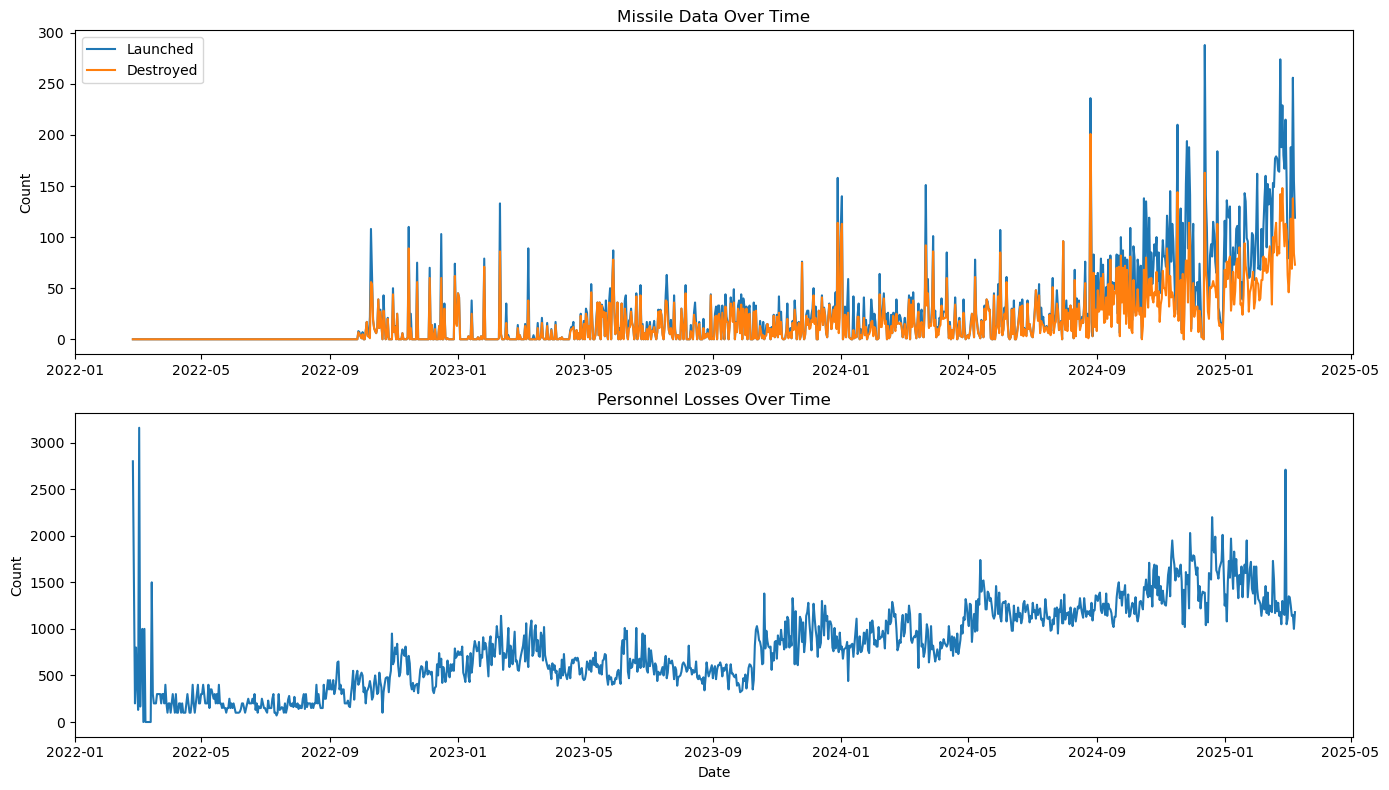

In [327]:
# Sort data by date for proper time series visualization
complete_df = complete_df.sort_values('date').reset_index(drop=True)

# Check the range of values for each column
print("Launched missiles range:", complete_df['launched'].min(), "to", complete_df['launched'].max())
print("Destroyed missiles range:", complete_df['destroyed'].min(), "to", complete_df['destroyed'].max())
print("Personnel losses range:", complete_df['daily_personnel_losses'].min(), "to", complete_df['daily_personnel_losses'].max())

# Basic time series plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

# Plot launched and destroyed missiles
plt.subplot(2, 1, 1)
plt.plot(complete_df['date'], complete_df['launched'], label='Launched')
plt.plot(complete_df['date'], complete_df['destroyed'], label='Destroyed')
plt.legend()
plt.title('Missile Data Over Time')
plt.ylabel('Count')

# Plot personnel losses
plt.subplot(2, 1, 2)
plt.plot(complete_df['date'], complete_df['daily_personnel_losses'])
plt.title('Personnel Losses Over Time')
plt.ylabel('Count')
plt.xlabel('Date')

plt.tight_layout()
plt.show()

In [329]:
# 1. Check for duplicated dates
duplicates = complete_df.duplicated(subset=['date'], keep=False)
if duplicates.any():
    print(f"WARNING: Found {duplicates.sum()} duplicate dates!")
    print(complete_df[duplicates])
else:
    print("✓ No duplicate dates found.")

# 2. Check for gaps in the date sequence
date_diff = complete_df['date'].diff().dt.days[1:]
if (date_diff != 1).any():
    gaps = complete_df.iloc[date_diff[date_diff != 1].index]
    print(f"WARNING: Found {(date_diff != 1).sum()} gaps in date sequence!")
    print(gaps)
else:
    print("✓ No gaps in date sequence.")

# 3. Check for logical inconsistencies
logical_error = complete_df['destroyed'] > complete_df['launched']
if logical_error.any():
    print(f"WARNING: Found {logical_error.sum()} days where destroyed > launched!")
    print(complete_df[logical_error])
else:
    print("✓ No logical errors in missile data (destroyed never exceeds launched).")

# 4. Check for negative values
neg_launched = (complete_df['launched'] < 0).sum()
neg_destroyed = (complete_df['destroyed'] < 0).sum()
neg_personnel = (complete_df['daily_personnel_losses'] < 0).sum()
if neg_launched or neg_destroyed or neg_personnel:
    print(f"WARNING: Found negative values in data!")
    print(f"  Negative launched: {neg_launched}")
    print(f"  Negative destroyed: {neg_destroyed}")
    print(f"  Negative personnel losses: {neg_personnel}")
else:
    print("✓ No negative values found.")

# 5. Check for outliers (using IQR method)
def check_outliers(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((series < lower_bound) | (series > upper_bound)) & (series > 0)
    if outliers.any():
        print(f"Possible outliers in {name}: {outliers.sum()} values")
        print(f"  Range for most data: {lower_bound:.1f} to {upper_bound:.1f}")
        print(f"  Outlier values: {series[outliers].sort_values(ascending=False).head()}")
    return outliers

# Check each column for outliers
for col in ['launched', 'destroyed', 'daily_personnel_losses']:
    check_outliers(complete_df[col], col)

# 6. Check for sudden changes in patterns (could indicate data collection changes)
complete_df['launched_7d_avg'] = complete_df['launched'].rolling(7).mean()
complete_df['destroyed_7d_avg'] = complete_df['destroyed'].rolling(7).mean()
complete_df['personnel_7d_avg'] = complete_df['daily_personnel_losses'].rolling(7).mean()

# 7. Check for correlation between columns
print("\nCorrelation between variables:")
print(complete_df[['launched', 'destroyed', 'daily_personnel_losses']].corr())

# 8. Check data completeness by time period
complete_df['year_month'] = complete_df['date'].dt.to_period('M')
monthly_completion = complete_df.groupby('year_month').agg(
    days=('date', 'count'),
    days_with_missiles=('launched', lambda x: (x > 0).sum()),
    days_with_personnel_data=('daily_personnel_losses', lambda x: x.notna().sum())
)
print("\nData completeness by month (sample):")
print(monthly_completion.head())

# 9. Check for seasonality by day of week
complete_df['day_of_week'] = complete_df['date'].dt.day_name()
dow_stats = complete_df.groupby('day_of_week').agg(
    avg_launched=('launched', 'mean'),
    avg_destroyed=('destroyed', 'mean'),
    avg_personnel=('daily_personnel_losses', 'mean')
)
print("\nDay of week patterns:")
print(dow_stats)

✓ No duplicate dates found.
✓ No gaps in date sequence.
✓ No logical errors in missile data (destroyed never exceeds launched).
✓ No negative values found.
Possible outliers in launched: 111 values
  Range for most data: -48.0 to 80.0
  Outlier values: 1022    288.0
1094    274.0
1106    256.0
913     236.0
1096    229.0
Name: launched, dtype: float64
Possible outliers in destroyed: 80 values
  Range for most data: -37.5 to 62.5
  Outlier values: 913     201.0
1022    163.0
1096    148.0
996     144.0
1094    142.0
Name: destroyed, dtype: float64
Possible outliers in daily_personnel_losses: 4 values
  Range for most data: -535.0 to 2145.0
  Outlier values: 6       3160
0       2800
1099    2710
1029    2200
Name: daily_personnel_losses, dtype: int64

Correlation between variables:
                        launched  destroyed  daily_personnel_losses
launched                1.000000   0.966030                0.529747
destroyed               0.966030   1.000000                0.511527
dail

In [331]:
# Find first date with missile data
first_missile_date = complete_df[complete_df['launched'] > 0]['date'].min()
print(f"First date with missile data: {first_missile_date}")

# Trim dataset to start from first missile date
missile_df = complete_df[complete_df['date'] >= first_missile_date].copy().reset_index(drop=True)

# Check the trimmed dataset
print(f"Original dataset: {len(complete_df)} days")
print(f"Trimmed dataset: {len(missile_df)} days")
print(f"Removed {len(complete_df) - len(missile_df)} days without missile data")

# Verify our trimmed dataset still contains all missile activity days
missile_days_original = (complete_df['launched'] > 0).sum()
missile_days_trimmed = (missile_df['launched'] > 0).sum()
print(f"Days with missile activity in original dataset: {missile_days_original}")
print(f"Days with missile activity in trimmed dataset: {missile_days_trimmed}")

# Check first few rows to confirm we have actual missile data now
print("\nFirst rows of trimmed dataset:")
print(missile_df.head())

First date with missile data: 2022-09-28 00:00:00
Original dataset: 1109 days
Trimmed dataset: 894 days
Removed 215 days without missile data
Days with missile activity in original dataset: 684
Days with missile activity in trimmed dataset: 684

First rows of trimmed dataset:
        date  launched  destroyed  daily_personnel_losses  launched_7d_avg  \
0 2022-09-28       8.0        7.0                     400         1.142857   
1 2022-09-29       7.0        5.0                     430         2.142857   
2 2022-09-30       3.0        3.0                     500         2.571429   
3 2022-10-01       1.0        1.0                     530         2.714286   
4 2022-10-02       7.0        5.0                     500         3.714286   

   destroyed_7d_avg  personnel_7d_avg year_month day_of_week  
0          1.000000        434.285714    2022-09   Wednesday  
1          1.714286        438.571429    2022-09    Thursday  
2          2.142857        431.428571    2022-09      Friday  
3 

In [333]:
missile_df.head()

,date,launched,destroyed,daily_personnel_losses,launched_7d_avg,destroyed_7d_avg,personnel_7d_avg,year_month,day_of_week
0,2022-09-28,8.0,7.0,400,1.142857,1.000000,434.285714,2022-09,Wednesday
1,2022-09-29,7.0,5.0,430,2.142857,1.714286,438.571429,2022-09,Thursday
2,2022-09-30,3.0,3.0,500,2.571429,2.142857,431.428571,2022-09,Friday
3,2022-10-01,1.0,1.0,530,2.714286,2.285714,472.857143,2022-10,Saturday
4,2022-10-02,7.0,5.0,500,3.714286,3.000000,487.142857,2022-10,Sunday


In [339]:
# Find first date with missile data
first_missile_date = complete_df[complete_df['launched'] > 0]['date'].min()
print(f"First date with missile data: {first_missile_date}")

# Trim dataset to start from first missile date
missile_df = complete_df[complete_df['date'] >= first_missile_date].copy().reset_index(drop=True)

# Remove unwanted columns
columns_to_drop = ['launched_7d_avg', 'destroyed_7d_avg', 'personnel_7d_avg', 'year_month']
for col in columns_to_drop:
    if col in missile_df.columns:
        missile_df = missile_df.drop(columns=[col])

# Make sure we have day_of_week (in case it wasn't created earlier)
if 'day_of_week' not in missile_df.columns:
    missile_df['day_of_week'] = missile_df['date'].dt.day_name()

# Check the final dataset structure
print("\nFinal dataset columns:")
print(missile_df.columns.tolist())

# Display sample data
print("\nSample of final dataset:")
print(missile_df.head())

# Save the cleaned dataset (optional)
# missile_df.to_csv('missile_data_clean.csv', index=False)

First date with missile data: 2022-09-28 00:00:00

Final dataset columns:
['date', 'launched', 'destroyed', 'daily_personnel_losses', 'day_of_week']

Sample of final dataset:
        date  launched  destroyed  daily_personnel_losses day_of_week
0 2022-09-28       8.0        7.0                     400   Wednesday
1 2022-09-29       7.0        5.0                     430    Thursday
2 2022-09-30       3.0        3.0                     500      Friday
3 2022-10-01       1.0        1.0                     530    Saturday
4 2022-10-02       7.0        5.0                     500      Sunday


# Add the weather Data

In [ ]:
#pip install openmeteo-requests requests_cache retry_requests

In [360]:
missile_df.head()

,date,launched,destroyed,daily_personnel_losses,day_of_week
0,2022-09-28,8.0,7.0,400,Wednesday
1,2022-09-29,7.0,5.0,430,Thursday
2,2022-09-30,3.0,3.0,500,Friday
3,2022-10-01,1.0,1.0,530,Saturday
4,2022-10-02,7.0,5.0,500,Sunday


In [384]:
# Install required packages if not already installed
# !pip install openmeteo-requests requests_cache retry_requests

import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

# Setup the Open-Meteo API client
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Get start and end dates from our missile dataset
start_date = missile_df['date'].min().strftime('%Y-%m-%d')
end_date = missile_df['date'].max().strftime('%Y-%m-%d')

print(f"Fetching weather data from {start_date} to {end_date}")

# Set coordinates for Kyiv, Ukraine
latitude = 50.4504
longitude = 30.5245

# Define API parameters for the entire date range
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "daily": ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean", 
              "precipitation_sum", "wind_speed_10m_max", "cloud_cover_mean"]
}

# Make the API request
response = openmeteo.weather_api(url, params=params)

# Process the response
daily = response[0].Daily()
daily_data = {
    "date": pd.date_range(start=start_date, end=end_date, freq='D'),
    "temp_max": daily.Variables(0).ValuesAsNumpy(),
    "temp_min": daily.Variables(1).ValuesAsNumpy(),
    "temp_mean": daily.Variables(2).ValuesAsNumpy(),
    "precip": daily.Variables(3).ValuesAsNumpy(),
    "wind_speed": daily.Variables(4).ValuesAsNumpy(),
    "cloud_cover": daily.Variables(5).ValuesAsNumpy()
}

# Create a weather dataframe
weather_df = pd.DataFrame(daily_data)

# Convert date to datetime to ensure proper merging
weather_df['date'] = pd.to_datetime(weather_df['date'])

# Verify the weather dataframe
print(f"Weather data shape: {weather_df.shape}")
print(weather_df.head())

# Merge with missile data
missile_weather_df = pd.merge(missile_df, weather_df, on='date', how='left')

# Verify the merged dataframe
print(f"\nMerged data shape: {missile_weather_df.shape}")
print(f"Original missile data shape: {missile_df.shape}")
print(f"Weather data shape: {weather_df.shape}")

# Check for any missing weather data
missing_weather = missile_weather_df[['temp_mean', 'precip', 'wind_speed']].isna().sum()
print("\nMissing weather data points:")
print(missing_weather)

# Display the first few rows of the merged dataframe
print("\nSample of merged data:")
print(missile_weather_df.head())

Fetching weather data from 2022-09-28 to 2025-03-09
Weather data shape: (894, 7)
        date   temp_max  temp_min  temp_mean     precip  wind_speed  \
0 2022-09-28  15.715500    8.1655  11.788418   1.100000   15.158522   
1 2022-09-29  17.465500    7.8155  12.698833   0.000000   16.808571   
2 2022-09-30  20.915501   11.1655  15.738418   6.400000   13.746156   
3 2022-10-01  20.315500   12.4155  15.473834  10.800001   19.809813   
4 2022-10-02  14.265500    7.4155  11.478000  15.600000   33.481934   

   cloud_cover  
0    72.875000  
1    94.500000  
2    70.958336  
3    92.000000  
4    98.958336  

Merged data shape: (894, 11)
Original missile data shape: (894, 5)
Weather data shape: (894, 7)

Missing weather data points:
temp_mean     0
precip        0
wind_speed    0
dtype: int64

Sample of merged data:
        date  launched  destroyed  daily_personnel_losses day_of_week  \
0 2022-09-28       8.0        7.0                     400   Wednesday   
1 2022-09-29       7.0        5.

In [399]:
missile_weather_df.head()

,date,launched,destroyed,daily_personnel_losses,day_of_week,temp_max,temp_min,temp_mean,precip,wind_speed,cloud_cover,week_start
0,2022-09-28,8.0,7.0,400,Wednesday,15.715500,8.1655,11.788418,1.100000,15.158522,72.875000,2022-09-26
1,2022-09-29,7.0,5.0,430,Thursday,17.465500,7.8155,12.698833,0.000000,16.808571,94.500000,2022-09-26
2,2022-09-30,3.0,3.0,500,Friday,20.915501,11.1655,15.738418,6.400000,13.746156,70.958336,2022-09-26
3,2022-10-01,1.0,1.0,530,Saturday,20.315500,12.4155,15.473834,10.800001,19.809813,92.000000,2022-09-26
4,2022-10-02,7.0,5.0,500,Sunday,14.265500,7.4155,11.478000,15.600000,33.481934,98.958336,2022-09-26


# EDA

/var/folders/ph/vn1yxmc909ld_37rxq3d0g1h0000gn/T/ipykernel_37552/4011811053.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_launches = missile_weather_df.set_index('date')['launched'].resample('M').mean()
/var/folders/ph/vn1yxmc909ld_37rxq3d0g1h0000gn/T/ipykernel_37552/4011811053.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_data.index, y=dow_data.values, palette='Blues_d', ax=ax4)


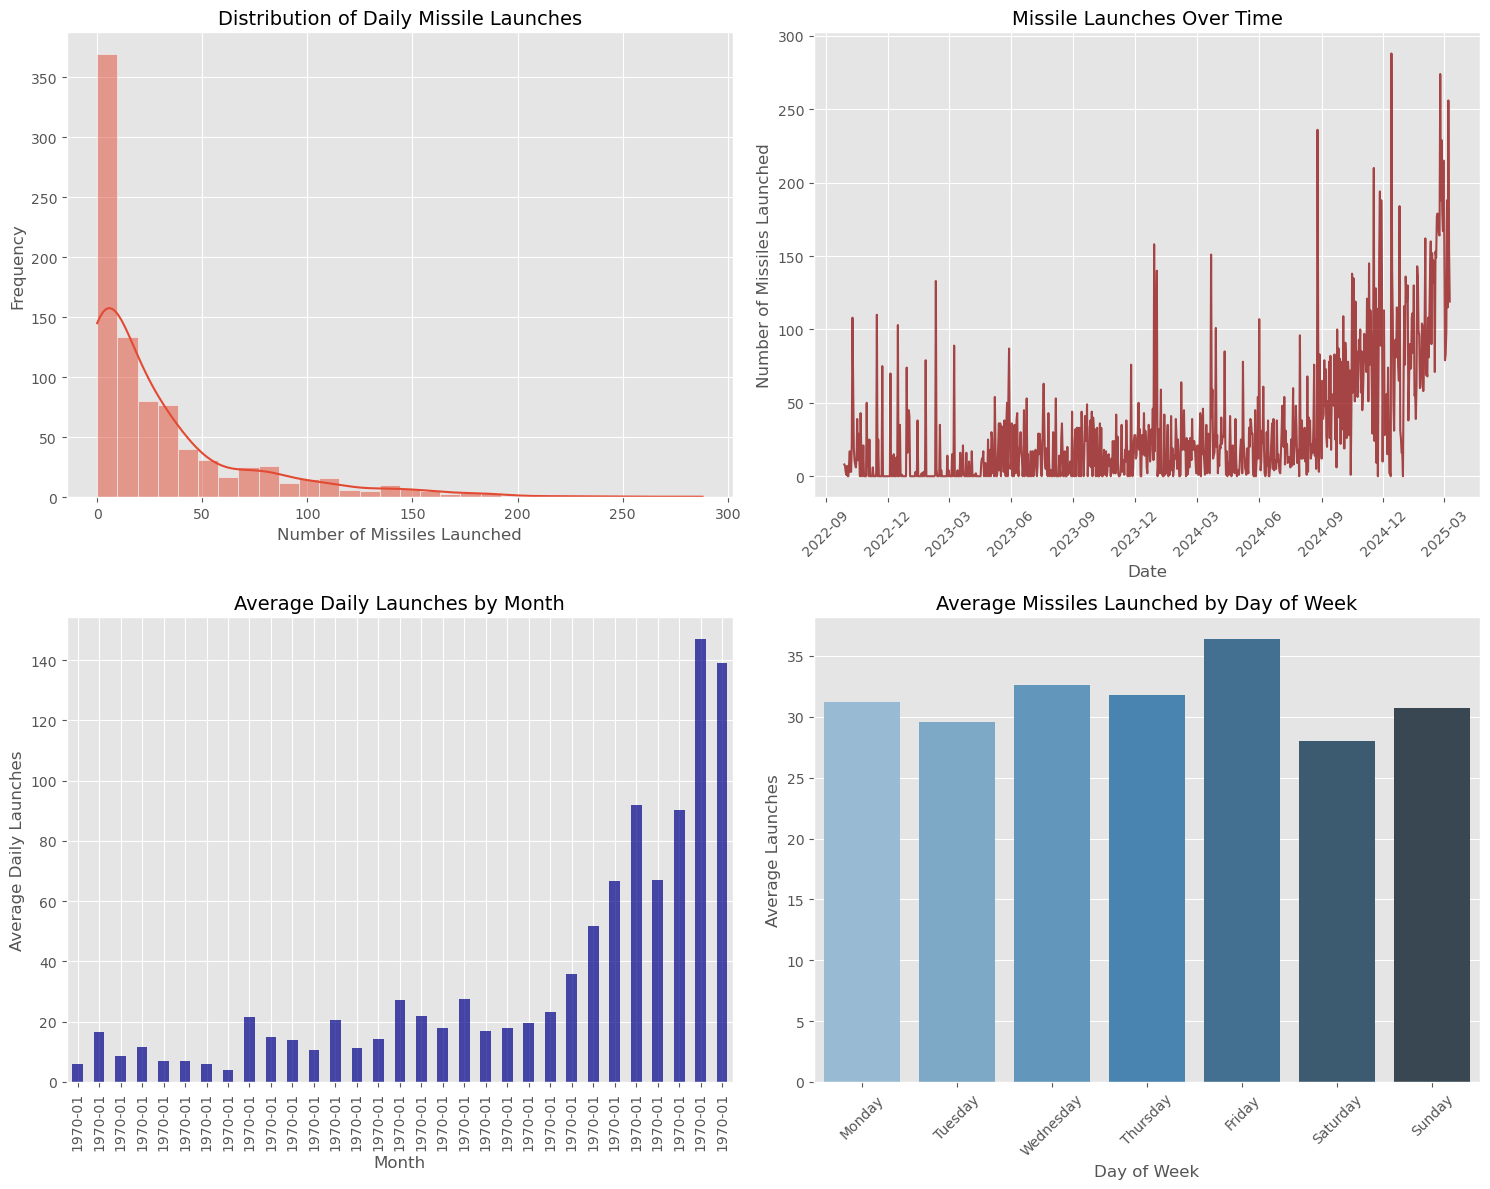

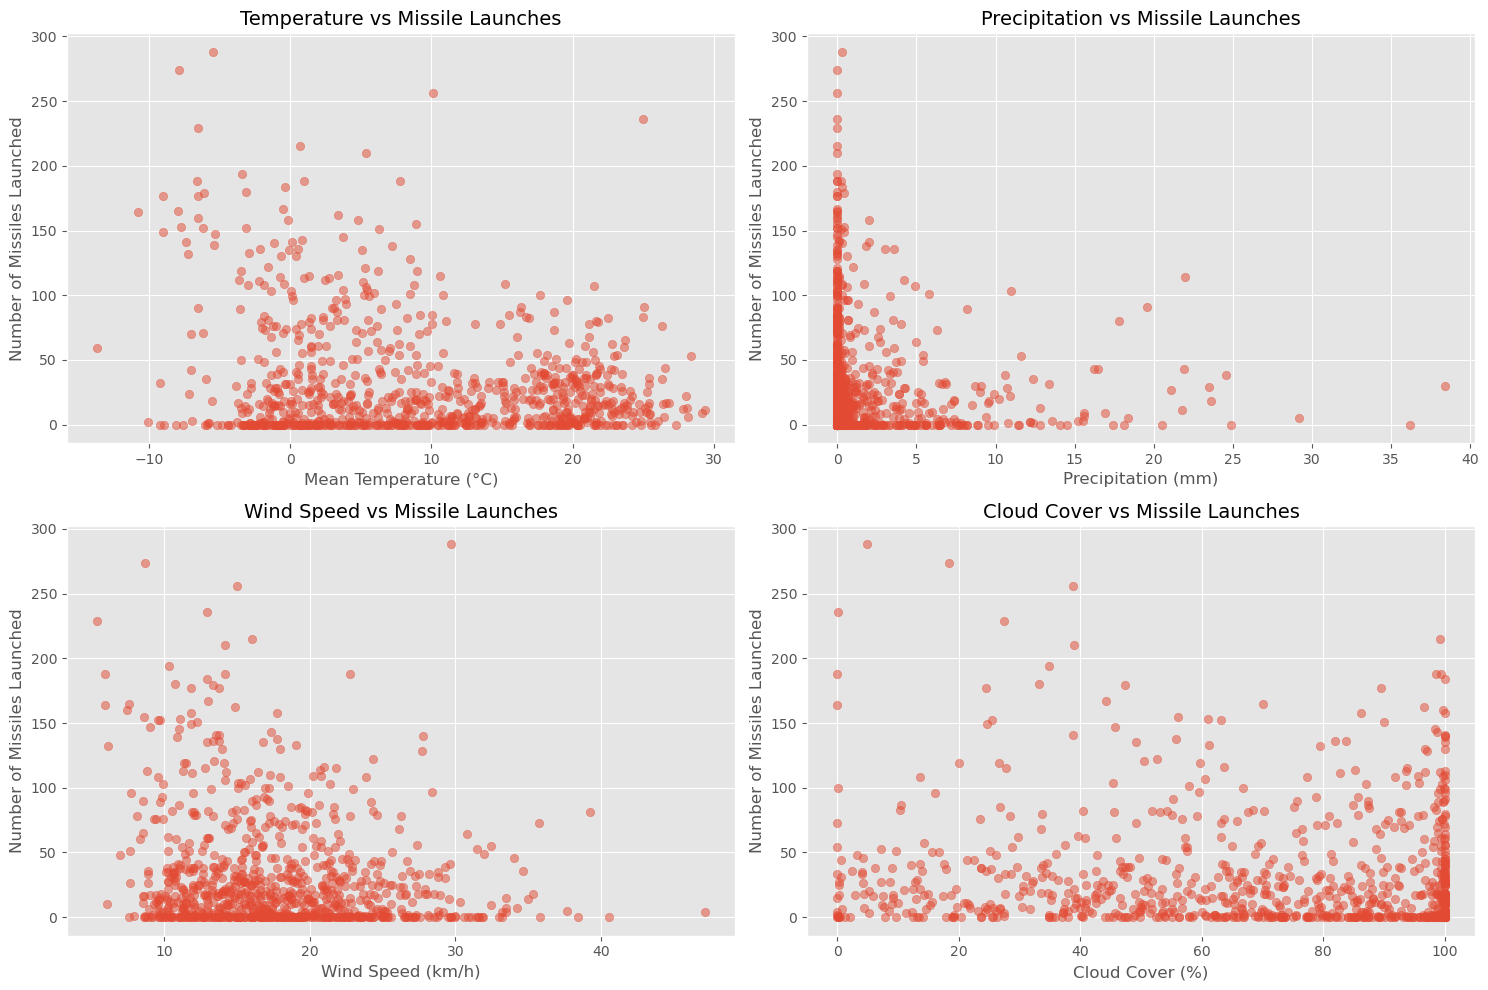

In [402]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

# Set up figure size and style
plt.style.use('ggplot')
fig = plt.figure(figsize=(15, 12))

# 1. Histogram of daily missile launches
ax1 = fig.add_subplot(2, 2, 1)
sns.histplot(missile_weather_df['launched'], bins=30, kde=True, ax=ax1)
ax1.set_title('Distribution of Daily Missile Launches', fontsize=14)
ax1.set_xlabel('Number of Missiles Launched', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)

# 2. Time series of missile launches
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(missile_weather_df['date'], missile_weather_df['launched'], color='darkred', alpha=0.7)
ax2.set_title('Missile Launches Over Time', fontsize=14)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Number of Missiles Launched', fontsize=12)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# 3. Monthly average launches
ax3 = fig.add_subplot(2, 2, 3)
monthly_launches = missile_weather_df.set_index('date')['launched'].resample('M').mean()
monthly_launches.plot(kind='bar', ax=ax3, color='darkblue', alpha=0.7)
ax3.set_title('Average Daily Launches by Month', fontsize=14)
ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('Average Daily Launches', fontsize=12)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=90)

# 4. Heatmap of launches by day of week and hour
ax4 = fig.add_subplot(2, 2, 4)
# Create day of week order (Monday first)
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_data = missile_weather_df.groupby('day_of_week')['launched'].mean().reindex(dow_order)
sns.barplot(x=dow_data.index, y=dow_data.values, palette='Blues_d', ax=ax4)
ax4.set_title('Average Missiles Launched by Day of Week', fontsize=14)
ax4.set_xlabel('Day of Week', fontsize=12)
ax4.set_ylabel('Average Launches', fontsize=12)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# 5. Additional plot: Launched vs Weather variables
fig2, axes = plt.subplots(2, 2, figsize=(15, 10))

# Temperature vs Launches
axes[0, 0].scatter(missile_weather_df['temp_mean'], missile_weather_df['launched'], alpha=0.5)
axes[0, 0].set_title('Temperature vs Missile Launches', fontsize=14)
axes[0, 0].set_xlabel('Mean Temperature (°C)', fontsize=12)
axes[0, 0].set_ylabel('Number of Missiles Launched', fontsize=12)

# Precipitation vs Launches
axes[0, 1].scatter(missile_weather_df['precip'], missile_weather_df['launched'], alpha=0.5)
axes[0, 1].set_title('Precipitation vs Missile Launches', fontsize=14)
axes[0, 1].set_xlabel('Precipitation (mm)', fontsize=12)
axes[0, 1].set_ylabel('Number of Missiles Launched', fontsize=12)

# Wind Speed vs Launches
axes[1, 0].scatter(missile_weather_df['wind_speed'], missile_weather_df['launched'], alpha=0.5)
axes[1, 0].set_title('Wind Speed vs Missile Launches', fontsize=14)
axes[1, 0].set_xlabel('Wind Speed (km/h)', fontsize=12)
axes[1, 0].set_ylabel('Number of Missiles Launched', fontsize=12)

# Cloud Cover vs Launches
axes[1, 1].scatter(missile_weather_df['cloud_cover'], missile_weather_df['launched'], alpha=0.5)
axes[1, 1].set_title('Cloud Cover vs Missile Launches', fontsize=14)
axes[1, 1].set_xlabel('Cloud Cover (%)', fontsize=12)
axes[1, 1].set_ylabel('Number of Missiles Launched', fontsize=12)

plt.tight_layout()
plt.show()

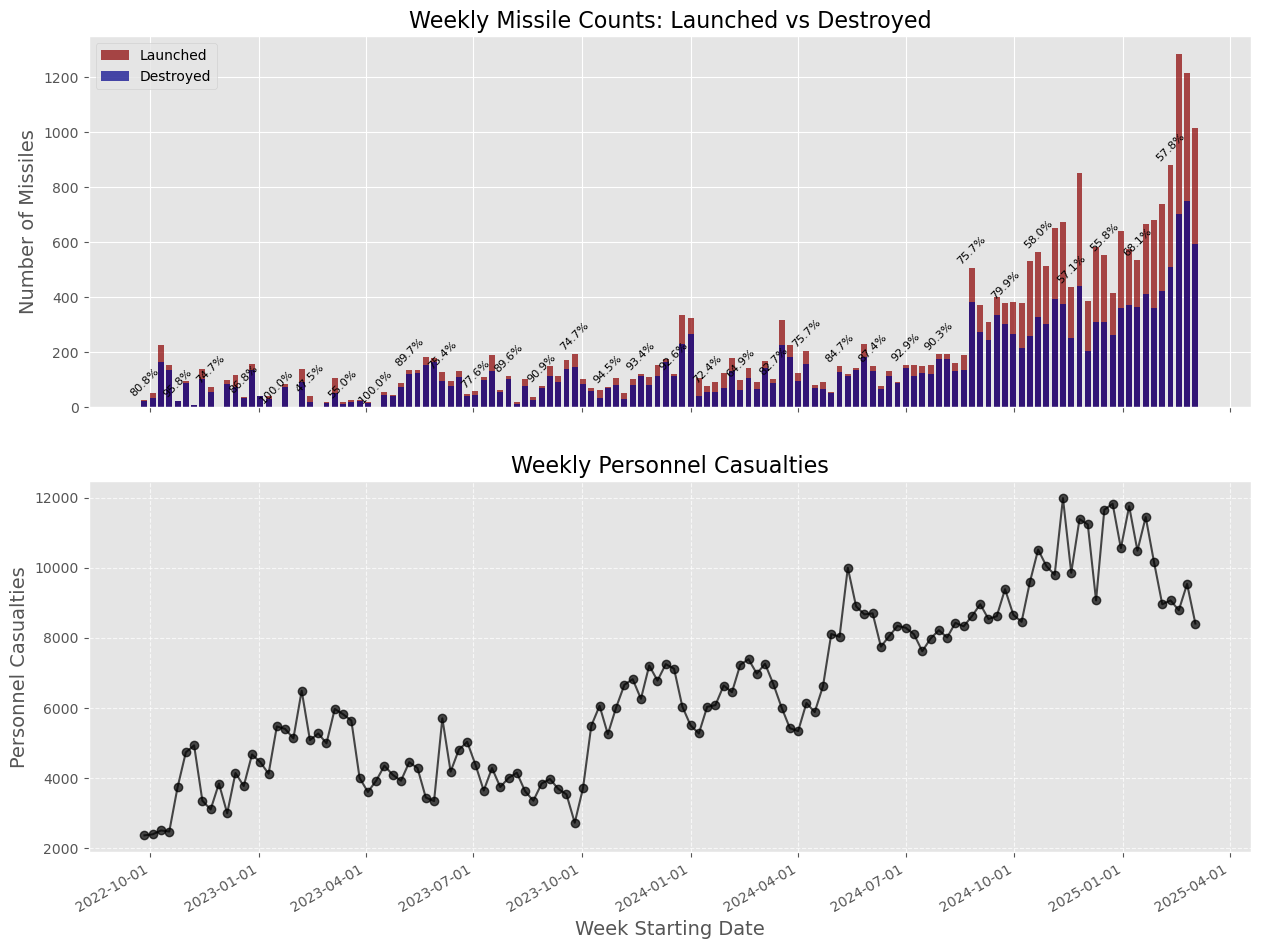

In [403]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create a proper weekly date for grouping
missile_weather_df['week_start'] = missile_weather_df['date'] - pd.to_timedelta(missile_weather_df['date'].dt.dayofweek, unit='d')

# Aggregate by week - sum up the values
weekly_data = missile_weather_df.groupby('week_start').agg({
    'launched': 'sum',
    'destroyed': 'sum',
    'daily_personnel_losses': 'sum'
}).reset_index()

# Sort by date to ensure correct order
weekly_data = weekly_data.sort_values('week_start')

# Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# 1. Weekly launched vs destroyed missiles plot
ax1.bar(weekly_data['week_start'], weekly_data['launched'], 
        width=5, label='Launched', color='darkred', alpha=0.7)
ax1.bar(weekly_data['week_start'], weekly_data['destroyed'], 
        width=5, label='Destroyed', color='darkblue', alpha=0.7)
ax1.set_title('Weekly Missile Counts: Launched vs Destroyed', fontsize=16)
ax1.set_ylabel('Number of Missiles', fontsize=14)
ax1.legend()

# Calculate and display the defense efficiency
for i, row in enumerate(weekly_data.itertuples()):
    if i % 4 == 0 and row.launched > 0:  # Show every 4th week to avoid crowding
        efficiency = (row.destroyed / row.launched) * 100
        ax1.text(row.week_start, row.launched + 5, f"{efficiency:.1f}%", 
                ha='center', va='bottom', fontsize=8, rotation=45)

# 2. Weekly casualties over time
ax2.plot(weekly_data['week_start'], weekly_data['daily_personnel_losses'], 
         marker='o', linestyle='-', color='black', alpha=0.7)
ax2.set_title('Weekly Personnel Casualties', fontsize=16)
ax2.set_xlabel('Week Starting Date', fontsize=14)
ax2.set_ylabel('Personnel Casualties', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)

# Format x-axis for better readability
plt.xticks(rotation=45)
fig.autofmt_xdate()

# Ensure dates are shown properly
from matplotlib.dates import DateFormatter
ax2.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))

# Add vertical lines for every 3 months to help with vis

/var/folders/ph/vn1yxmc909ld_37rxq3d0g1h0000gn/T/ipykernel_37552/2294570079.py:86: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  quarter_starts = pd.date_range(start=start_date, end=end_date, freq='3M')


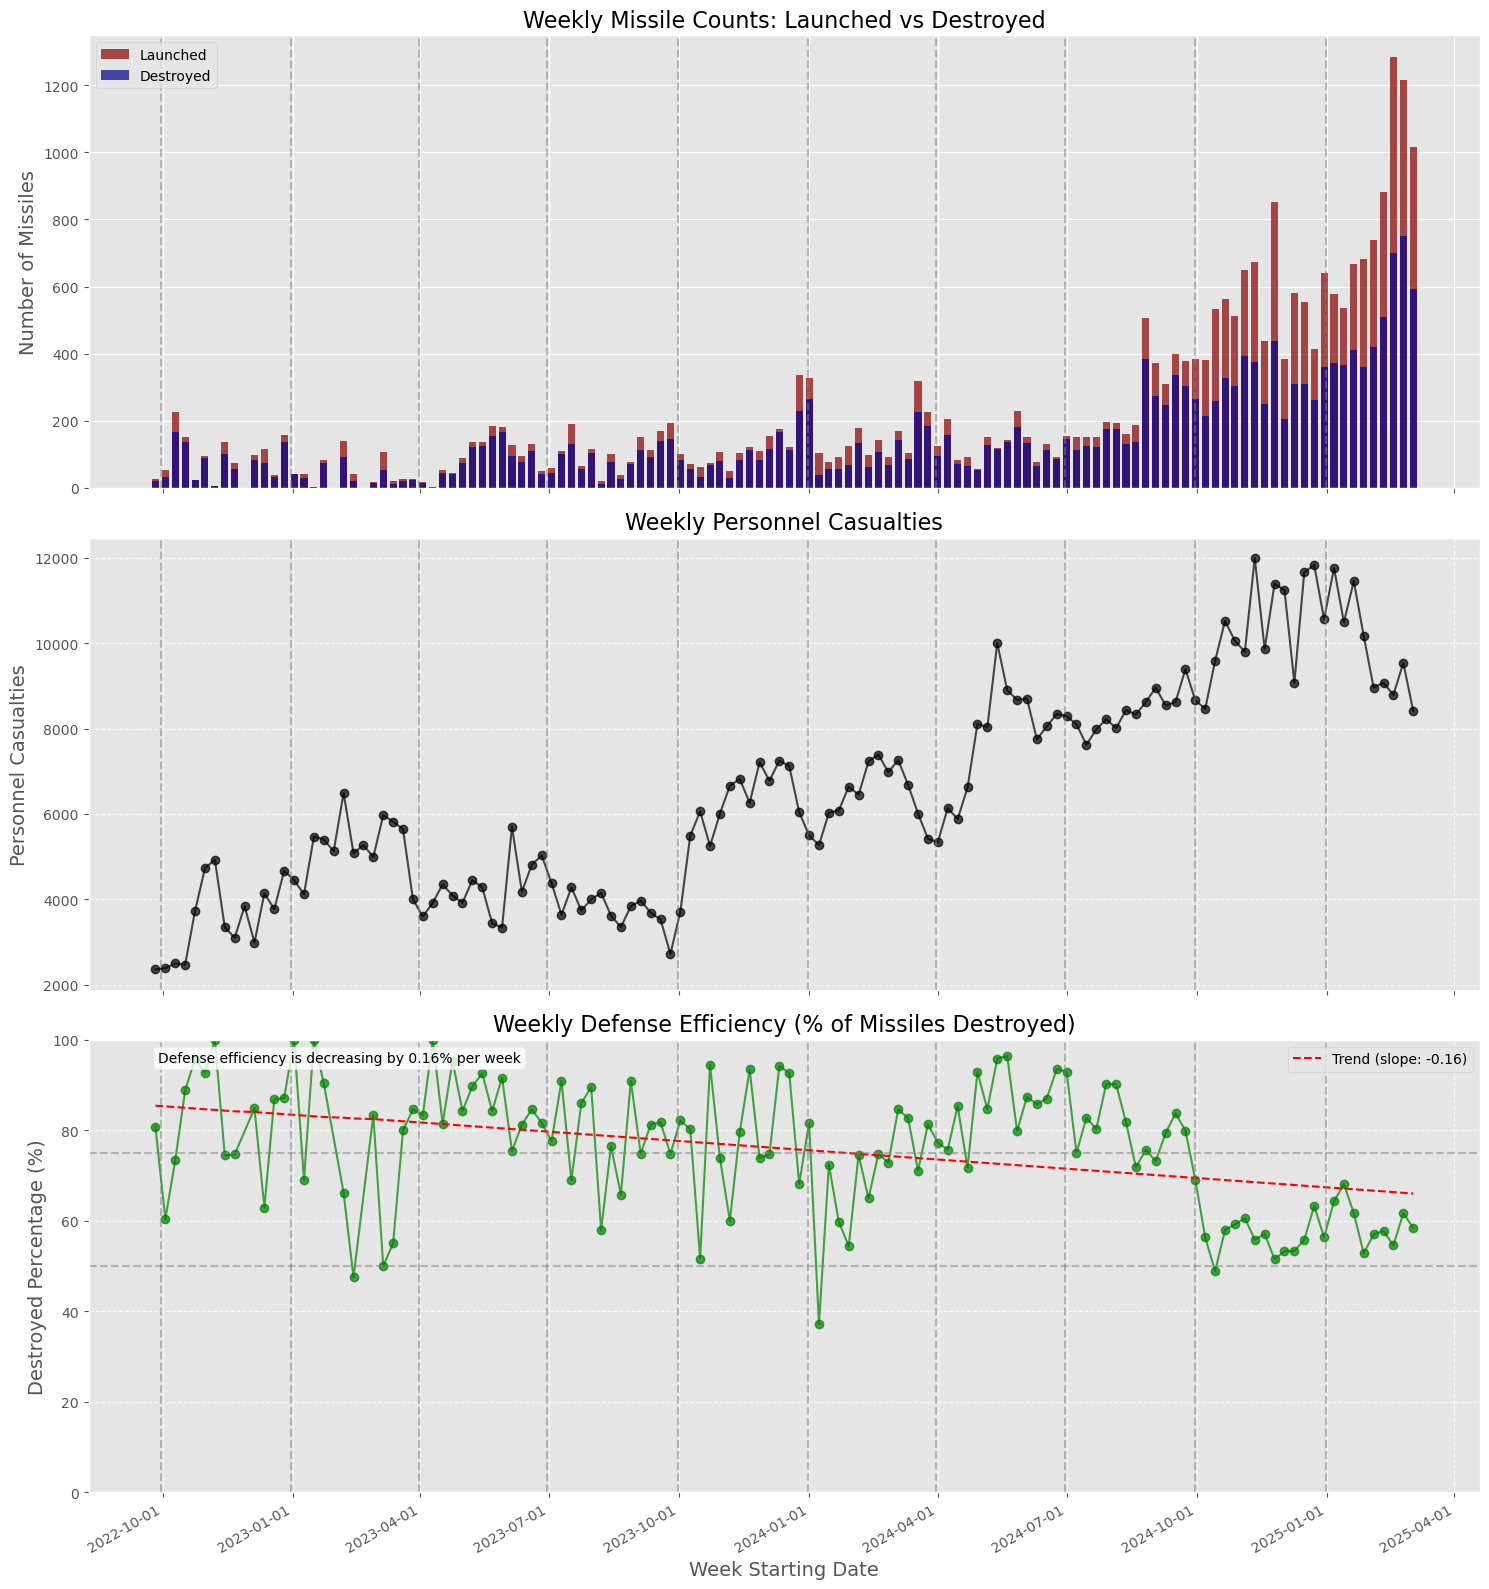

In [404]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.dates import DateFormatter
from scipy import stats

# Create a proper weekly date for grouping
missile_weather_df['week_start'] = missile_weather_df['date'] - pd.to_timedelta(missile_weather_df['date'].dt.dayofweek, unit='d')

# Aggregate by week - sum up the values
weekly_data = missile_weather_df.groupby('week_start').agg({
    'launched': 'sum',
    'destroyed': 'sum',
    'daily_personnel_losses': 'sum'
}).reset_index()

# Sort by date to ensure correct order
weekly_data = weekly_data.sort_values('week_start')

# Calculate weekly destroyed percentage (defense efficiency)
weekly_data['destroyed_pct'] = np.where(
    weekly_data['launched'] > 0,
    (weekly_data['destroyed'] / weekly_data['launched']) * 100,
    0  # Handle weeks with no launches
)

# Create the figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 16), sharex=True)

# 1. Weekly launched vs destroyed missiles plot
ax1.bar(weekly_data['week_start'], weekly_data['launched'], 
        width=5, label='Launched', color='darkred', alpha=0.7)
ax1.bar(weekly_data['week_start'], weekly_data['destroyed'], 
        width=5, label='Destroyed', color='darkblue', alpha=0.7)
ax1.set_title('Weekly Missile Counts: Launched vs Destroyed', fontsize=16)
ax1.set_ylabel('Number of Missiles', fontsize=14)
ax1.legend()

# 2. Weekly casualties over time
ax2.plot(weekly_data['week_start'], weekly_data['daily_personnel_losses'], 
         marker='o', linestyle='-', color='black', alpha=0.7)
ax2.set_title('Weekly Personnel Casualties', fontsize=16)
ax2.set_ylabel('Personnel Casualties', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)

# 3. Weekly destroyed percentage (efficiency) over time
# Only include weeks with launches
valid_weeks = weekly_data[weekly_data['launched'] > 0]
ax3.plot(valid_weeks['week_start'], valid_weeks['destroyed_pct'], 
         marker='o', linestyle='-', color='green', alpha=0.7)
ax3.set_title('Weekly Defense Efficiency (% of Missiles Destroyed)', fontsize=16)
ax3.set_xlabel('Week Starting Date', fontsize=14)
ax3.set_ylabel('Destroyed Percentage (%)', fontsize=14)
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.set_ylim(0, 100)

# Add a trend line to the efficiency plot
if len(valid_weeks) > 1:
    # Convert dates to numeric for regression
    x_numeric = np.arange(len(valid_weeks))
    y = valid_weeks['destroyed_pct']
    
    # Calculate trend line
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_numeric, y)
    trend_line = intercept + slope * x_numeric
    
    # Add trend line to plot
    ax3.plot(valid_weeks['week_start'], trend_line, 'r--', 
             label=f'Trend (slope: {slope:.2f})')
    ax3.legend()
    
    # Add annotation about trend
    trend_direction = "increasing" if slope > 0 else "decreasing"
    ax3.annotate(f"Defense efficiency is {trend_direction} by {abs(slope):.2f}% per week", 
                xy=(0.05, 0.95), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

# Format x-axis for better readability
plt.xticks(rotation=45)
fig.autofmt_xdate()
ax3.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))

# Add vertical lines for every 3 months to help with visual reference
start_date = weekly_data['week_start'].min()
end_date = weekly_data['week_start'].max()
quarter_starts = pd.date_range(start=start_date, end=end_date, freq='3M')
for date in quarter_starts:
    ax1.axvline(x=date, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=date, color='gray', linestyle='--', alpha=0.5)
    ax3.axvline(x=date, color='gray', linestyle='--', alpha=0.5)

# Add horizontal line at 50% and 75% as reference points for efficiency
ax3.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax3.axhline(y=75, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/var/folders/ph/vn1yxmc909ld_37rxq3d0g1h0000gn/T/ipykernel_37552/1804849916.py:72: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  quarter_starts = pd.date_range(start=start_date, end=end_date, freq='3M')


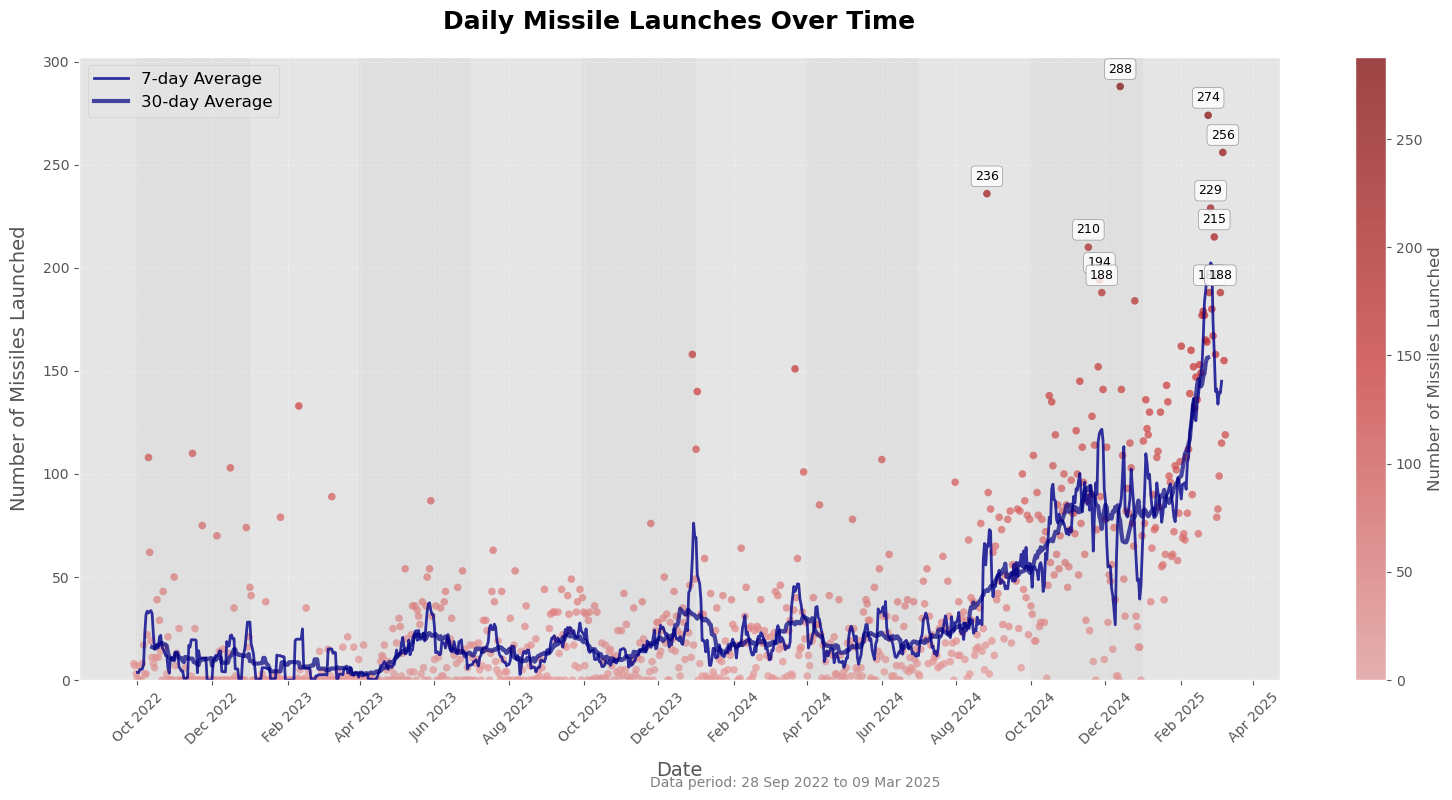

In [408]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

# Sort data by date
daily_data = missile_weather_df.sort_values('date')

# Create figure
fig, ax = plt.subplots(figsize=(16, 8))

# Create custom colormap - from light to dark red for intensity
colors = [(0.9, 0.6, 0.6), (0.8, 0.2, 0.2), (0.5, 0, 0)]  # Light red to dark red
cmap = LinearSegmentedColormap.from_list("custom_reds", colors, N=100)

# Plot daily launches with gradient color based on number of launches
scatter = ax.scatter(daily_data['date'], daily_data['launched'], 
           c=daily_data['launched'], cmap=cmap,
           alpha=0.7, s=30, edgecolor='none')

# Add 7-day moving average line
daily_data['launched_7d_avg'] = daily_data['launched'].rolling(window=7, center=True).mean()
ax.plot(daily_data['date'], daily_data['launched_7d_avg'], 
        color='darkblue', linewidth=2, alpha=0.8, label='7-day Average')

# Add 30-day moving average line
daily_data['launched_30d_avg'] = daily_data['launched'].rolling(window=30, center=True).mean()
ax.plot(daily_data['date'], daily_data['launched_30d_avg'], 
        color='navy', linewidth=3, alpha=0.7, label='30-day Average')

# Find and highlight significant events (days with exceptionally high launches)
threshold = daily_data['launched'].quantile(0.99)  # Top 1% of launch days
significant_days = daily_data[daily_data['launched'] >= threshold]

for idx, day in significant_days.iterrows():
    ax.annotate(f"{int(day['launched'])}", 
                xy=(day['date'], day['launched']),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc='white', ec="gray", alpha=0.8))

# Set title and labels with better fonts
ax.set_title('Daily Missile Launches Over Time', fontsize=18, pad=20, fontweight='bold')
ax.set_xlabel('Date', fontsize=14, labelpad=10)
ax.set_ylabel('Number of Missiles Launched', fontsize=14, labelpad=10)

# Improve x-axis date formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Show every 2 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format: "Jan 2023"
plt.xticks(rotation=45)

# Add colorbar to show intensity scale
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Number of Missiles Launched', fontsize=12)

# Set y-axis to start at 0
ax.set_ylim(bottom=0)

# Add grid but make it subtle
ax.grid(True, linestyle='--', alpha=0.3)

# Add legend
ax.legend(fontsize=12)

# Add background shading for quarters to help with visual reference
start_date = daily_data['date'].min()
end_date = daily_data['date'].max()
quarter_starts = pd.date_range(start=start_date, end=end_date, freq='3M')

for i, date in enumerate(quarter_starts):
    if i % 2 == 0 and i+1 < len(quarter_starts):  # Every other quarter
        ax.axvspan(date, quarter_starts[i+1], color='gray', alpha=0.05)

# Ensure the figure looks clean
fig.tight_layout()

# Add a subtle text watermark with data timeframe
timeframe_text = f"Data period: {start_date.strftime('%d %b %Y')} to {end_date.strftime('%d %b %Y')}"
fig.text(0.5, 0.01, timeframe_text, ha='center', fontsize=10, color='gray')

plt.show()

# Modeling

In [410]:
# Rename missile_weather_df to df
df = missile_weather_df

# Verify it worked
print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (894, 12)


,date,launched,destroyed,daily_personnel_losses,day_of_week,temp_max,temp_min,temp_mean,precip,wind_speed,cloud_cover,week_start
0,2022-09-28,8.0,7.0,400,Wednesday,15.715500,8.1655,11.788418,1.100000,15.158522,72.875000,2022-09-26
1,2022-09-29,7.0,5.0,430,Thursday,17.465500,7.8155,12.698833,0.000000,16.808571,94.500000,2022-09-26
2,2022-09-30,3.0,3.0,500,Friday,20.915501,11.1655,15.738418,6.400000,13.746156,70.958336,2022-09-26
3,2022-10-01,1.0,1.0,530,Saturday,20.315500,12.4155,15.473834,10.800001,19.809813,92.000000,2022-09-26
4,2022-10-02,7.0,5.0,500,Sunday,14.265500,7.4155,11.478000,15.600000,33.481934,98.958336,2022-09-26


In [412]:
#Add and Encode Day of the Week Feature

# Ensure date is in datetime format first
df['date'] = pd.to_datetime(df['date'])

# Method 1: Get day of week as number (0=Monday, 6=Sunday)
df['day_of_week_num'] = df['date'].dt.dayofweek

# Convert to your preferred encoding (1=Monday, 7=Sunday)
df['day_of_week_num'] = df['day_of_week_num'] + 1

# Method 2: Get day name as string
df['day_of_week'] = df['date'].dt.day_name()

# Verify the extraction worked
print(df[['date', 'day_of_week_num', 'day_of_week']].head())

        date  day_of_week_num day_of_week
0 2022-09-28                3   Wednesday
1 2022-09-29                4    Thursday
2 2022-09-30                5      Friday
3 2022-10-01                6    Saturday
4 2022-10-02                7      Sunday


In [414]:
df.head()

,date,launched,destroyed,daily_personnel_losses,day_of_week,temp_max,temp_min,temp_mean,precip,wind_speed,cloud_cover,week_start,day_of_week_num
0,2022-09-28,8.0,7.0,400,Wednesday,15.715500,8.1655,11.788418,1.100000,15.158522,72.875000,2022-09-26,3
1,2022-09-29,7.0,5.0,430,Thursday,17.465500,7.8155,12.698833,0.000000,16.808571,94.500000,2022-09-26,4
2,2022-09-30,3.0,3.0,500,Friday,20.915501,11.1655,15.738418,6.400000,13.746156,70.958336,2022-09-26,5
3,2022-10-01,1.0,1.0,530,Saturday,20.315500,12.4155,15.473834,10.800001,19.809813,92.000000,2022-09-26,6
4,2022-10-02,7.0,5.0,500,Sunday,14.265500,7.4155,11.478000,15.600000,33.481934,98.958336,2022-09-26,7


## Feature Engineer: Time Based Features

In [416]:
# Ensure the 'date' column is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Extract basic date features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# Add quarter of the year (1-4)
df['quarter'] = df['date'].dt.quarter

# Create weekend indicator (assuming day_of_week_num uses 1-7 with 6,7 as weekend)
df['is_weekend'] = (df['day_of_week_num'].isin([6, 7])).astype(int)

# Add day of year (1-365)
df['day_of_year'] = df['date'].dt.dayofyear

# Create cyclical features for month to capture seasonality
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Create cyclical features for day_of_week_num (using your 1-7 encoding)
df['day_of_week_sin'] = np.sin(2 * np.pi * (df['day_of_week_num'] - 1) / 7)  # Subtract 1 to make it 0-6 for the calculation
df['day_of_week_cos'] = np.cos(2 * np.pi * (df['day_of_week_num'] - 1) / 7)

# Add season indicator (Northern Hemisphere)
# Winter: Dec(12), Jan(1), Feb(2); Spring: Mar(3), Apr(4), May(5)
# Summer: Jun(6), Jul(7), Aug(8); Fall: Sep(9), Oct(10), Nov(11)
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter', 
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer', 
              9: 'Fall', 10: 'Fall', 11: 'Fall'}
df['season'] = df['month'].map(season_map)

# Create one-hot encoding for seasons
season_dummies = pd.get_dummies(df['season'], prefix='season')
df = pd.concat([df, season_dummies], axis=1)

# Create days since start of the dataset (temporal distance feature)
df['days_since_start'] = (df['date'] - df['date'].min()).dt.days

df.head()

,date,launched,destroyed,daily_personnel_losses,day_of_week,temp_max,temp_min,temp_mean,precip,wind_speed,cloud_cover,week_start,day_of_week_num,year,month,day,quarter,is_weekend,day_of_year,month_sin,month_cos,day_of_week_sin,day_of_week_cos,season,season_Fall,season_Spring,season_Summer,season_Winter,days_since_start
0,2022-09-28,8.0,7.0,400,Wednesday,15.715500,8.1655,11.788418,1.100000,15.158522,72.875000,2022-09-26,3,2022,9,28,3,0,271,-1.000000,-1.836970e-16,0.974928,-0.222521,Fall,True,False,False,False,0
1,2022-09-29,7.0,5.0,430,Thursday,17.465500,7.8155,12.698833,0.000000,16.808571,94.500000,2022-09-26,4,2022,9,29,3,0,272,-1.000000,-1.836970e-16,0.433884,-0.900969,Fall,True,False,False,False,1
2,2022-09-30,3.0,3.0,500,Friday,20.915501,11.1655,15.738418,6.400000,13.746156,70.958336,2022-09-26,5,2022,9,30,3,0,273,-1.000000,-1.836970e-16,-0.433884,-0.900969,Fall,True,False,False,False,2
3,2022-10-01,1.0,1.0,530,Saturday,20.315500,12.4155,15.473834,10.800001,19.809813,92.000000,2022-09-26,6,2022,10,1,4,1,274,-0.866025,5.000000e-01,-0.974928,-0.222521,Fall,True,False,False,False,3
4,2022-10-02,7.0,5.0,500,Sunday,14.265500,7.4155,11.478000,15.600000,33.481934,98.958336,2022-09-26,7,2022,10,2,4,1,275,-0.866025,5.000000e-01,-0.781831,0.623490,Fall,True,False,False,False,4


## Feature Engineering: Lag Features

In [422]:
# Strategic lag timeframes for military operations
# Short-term tactical response
df['launched_lag1'] = df['launched'].shift(1)  # Previous day
df['launched_lag1'] = df['launched'].shift(2)  # 2 days ago
df['launched_lag3'] = df['launched'].shift(3)  # Three days ago

# Medium-term operational patterns
df['launched_lag7'] = df['launched'].shift(7)  # Weekly cycle
df['launched_lag14'] = df['launched'].shift(14)  # Bi-weekly cycle

# Long-term strategic patterns
df['launched_lag30'] = df['launched'].shift(30)  # Monthly cycle

# Trend indicators (rolling windows)
df['launched_roll7'] = df['launched'].rolling(window=7).mean()  # Weekly average
df['launched_roll30'] = df['launched'].rolling(window=30).mean()  # Monthly average

# For daily_personnel_losses
# Short-term tactical patterns
df['personnel_lag1'] = df['daily_personnel_losses'].shift(1)
df['personnel_lag3'] = df['daily_personnel_losses'].shift(3)

# Medium-term operational patterns  
df['personnel_lag7'] = df['daily_personnel_losses'].shift(7)
df['personnel_lag14'] = df['daily_personnel_losses'].shift(14)

# Long-term strategic patterns
df['personnel_lag30'] = df['daily_personnel_losses'].shift(30)

# Trend indicators
df['personnel_roll7'] = df['daily_personnel_losses'].rolling(window=7).mean()
df['personnel_roll30'] = df['daily_personnel_losses'].rolling(window=30).mean()


# For destroyed
# Short-term tactical patterns
df['destroyed_lag1'] = df['destroyed'].shift(1)
df['destroyed_lag3'] = df['destroyed'].shift(3)

# Medium-term operational patterns
df['destroyed_lag7'] = df['destroyed'].shift(7) 
df['destroyed_lag14'] = df['destroyed'].shift(14)

# Long-term strategic patterns
df['destroyed_lag30'] = df['destroyed'].shift(30)

# Trend indicators
df['destroyed_roll7'] = df['destroyed'].rolling(window=7).mean()
df['destroyed_roll30'] = df['destroyed'].rolling(window=30).mean()

# Handle the introduced NaN values
df = df.dropna()

In [424]:
df.head()

,date,launched,destroyed,daily_personnel_losses,day_of_week,temp_max,temp_min,temp_mean,precip,wind_speed,cloud_cover,week_start,day_of_week_num,year,month,day,quarter,is_weekend,day_of_year,month_sin,month_cos,day_of_week_sin,day_of_week_cos,season,season_Fall,season_Spring,season_Summer,season_Winter,days_since_start,launched_lag1,launched_lag3,launched_lag7,launched_lag14,launched_lag30,launched_roll7,launched_roll30,personnel_lag1,personnel_lag3,personnel_lag7,personnel_lag14,personnel_lag30,personnel_roll7,personnel_roll30,destroyed_lag1,destroyed_lag3,destroyed_lag7,destroyed_lag14,destroyed_lag30,destroyed_roll7,destroyed_roll30
30,2022-10-28,0.0,0.0,480,Friday,13.815499,6.6655,10.475917,0.0,11.119281,89.083336,2022-10-24,5,2022,10,28,4,0,301,-0.866025,0.500000,-0.433884,-0.900969,Fall,True,False,False,False,30,21.0,3.0,0.0,8.0,8.0,11.857143,15.733333,320.0,480.0,100.0,500.0,400.0,421.428571,385.0,0.0,3.0,0.0,8.0,7.0,9.571429,12.300000
31,2022-10-29,0.0,0.0,550,Saturday,16.515501,7.8655,12.750916,0.1,23.510508,85.125000,2022-10-24,6,2022,10,29,4,1,302,-0.866025,0.500000,-0.974928,-0.222521,Fall,True,False,False,False,31,0.0,21.0,43.0,6.0,7.0,5.714286,15.500000,480.0,480.0,320.0,400.0,430.0,454.285714,389.0,0.0,20.0,28.0,6.0,5.0,5.571429,12.133333
32,2022-10-30,0.0,0.0,950,Sunday,13.415500,8.9655,11.223834,0.7,22.668570,90.166664,2022-10-24,7,2022,10,30,4,1,303,-0.866025,0.500000,-0.781831,0.623490,Fall,True,False,False,False,32,0.0,0.0,16.0,11.0,3.0,3.428571,15.400000,550.0,320.0,400.0,300.0,500.0,532.857143,404.0,0.0,0.0,16.0,11.0,3.0,3.285714,12.033333
33,2022-10-31,50.0,44.0,620,Monday,9.565499,2.1155,6.682166,0.0,25.620771,16.791666,2022-10-31,1,2022,10,31,4,0,304,-0.866025,0.500000,0.000000,1.000000,Fall,True,False,False,False,33,0.0,0.0,0.0,39.0,1.0,10.571429,17.033333,950.0,480.0,470.0,320.0,530.0,554.285714,407.0,0.0,0.0,0.0,39.0,1.0,9.571429,13.466667
34,2022-11-01,7.0,7.0,650,Tuesday,9.065499,0.6155,4.867583,0.0,11.298495,39.875000,2022-10-31,2,2022,11,1,4,0,305,-0.500000,0.866025,0.781831,0.623490,Fall,True,False,False,False,34,0.0,0.0,3.0,11.0,7.0,11.142857,17.033333,620.0,550.0,480.0,530.0,500.0,578.571429,412.0,44.0,0.0,3.0,11.0,5.0,10.142857,13.533333


In [430]:
df.head()

,date,launched,destroyed,daily_personnel_losses,day_of_week,temp_max,temp_min,temp_mean,precip,wind_speed,cloud_cover,week_start,day_of_week_num,year,month,day,quarter,is_weekend,day_of_year,month_sin,month_cos,day_of_week_sin,day_of_week_cos,season,season_Fall,season_Spring,season_Summer,season_Winter,days_since_start,launched_lag1,launched_lag3,launched_lag7,launched_lag14,launched_lag30,launched_roll7,launched_roll30,personnel_lag1,personnel_lag3,personnel_lag7,personnel_lag14,personnel_lag30,personnel_roll7,personnel_roll30,destroyed_lag1,destroyed_lag3,destroyed_lag7,destroyed_lag14,destroyed_lag30,destroyed_roll7,destroyed_roll30
30,2022-10-28,0.0,0.0,480,Friday,13.815499,6.6655,10.475917,0.0,11.119281,89.083336,2022-10-24,5,2022,10,28,4,0,301,-0.866025,0.500000,-0.433884,-0.900969,Fall,True,False,False,False,30,21.0,3.0,0.0,8.0,8.0,11.857143,15.733333,320.0,480.0,100.0,500.0,400.0,421.428571,385.0,0.0,3.0,0.0,8.0,7.0,9.571429,12.300000
31,2022-10-29,0.0,0.0,550,Saturday,16.515501,7.8655,12.750916,0.1,23.510508,85.125000,2022-10-24,6,2022,10,29,4,1,302,-0.866025,0.500000,-0.974928,-0.222521,Fall,True,False,False,False,31,0.0,21.0,43.0,6.0,7.0,5.714286,15.500000,480.0,480.0,320.0,400.0,430.0,454.285714,389.0,0.0,20.0,28.0,6.0,5.0,5.571429,12.133333
32,2022-10-30,0.0,0.0,950,Sunday,13.415500,8.9655,11.223834,0.7,22.668570,90.166664,2022-10-24,7,2022,10,30,4,1,303,-0.866025,0.500000,-0.781831,0.623490,Fall,True,False,False,False,32,0.0,0.0,16.0,11.0,3.0,3.428571,15.400000,550.0,320.0,400.0,300.0,500.0,532.857143,404.0,0.0,0.0,16.0,11.0,3.0,3.285714,12.033333
33,2022-10-31,50.0,44.0,620,Monday,9.565499,2.1155,6.682166,0.0,25.620771,16.791666,2022-10-31,1,2022,10,31,4,0,304,-0.866025,0.500000,0.000000,1.000000,Fall,True,False,False,False,33,0.0,0.0,0.0,39.0,1.0,10.571429,17.033333,950.0,480.0,470.0,320.0,530.0,554.285714,407.0,0.0,0.0,0.0,39.0,1.0,9.571429,13.466667
34,2022-11-01,7.0,7.0,650,Tuesday,9.065499,0.6155,4.867583,0.0,11.298495,39.875000,2022-10-31,2,2022,11,1,4,0,305,-0.500000,0.866025,0.781831,0.623490,Fall,True,False,False,False,34,0.0,0.0,3.0,11.0,7.0,11.142857,17.033333,620.0,550.0,480.0,530.0,500.0,578.571429,412.0,44.0,0.0,3.0,11.0,5.0,10.142857,13.533333


In [432]:
df_dropped_col1 = df.drop('day_of_week', 'date','week_start'  axis=1)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3737283801.py, line 1)

In [446]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# First, let's make a copy of our dataframe for safety
df_model = df.copy()

# Columns to drop
columns_to_drop = ['day_of_week', 'week_start', 'season']
df_model = df_model.drop(columns=columns_to_drop)

## Scaling

In [449]:
# Keep date but exclude from features for scaling/modeling
date_col = df_model['date'].copy()

# Identify columns for scaling
# Exclude date, categorical, and one-hot encoded columns
exclude_from_scaling = ['date', 'season_Fall', 'season_Spring', 'season_Summer', 'season_Winter']
columns_to_scale = [col for col in df_model.columns if col not in exclude_from_scaling and df_model[col].dtype != 'object']

# Initialize the scaler
scaler = MinMaxScaler()

# Apply scaling
df_model[columns_to_scale] = scaler.fit_transform(df_model[columns_to_scale])

# Verify scaling worked by checking range
print("Scaled data ranges:")
for col in columns_to_scale[:5]:  # Show just first 5 for brevity
    print(f"{col}: {df_model[col].min()} to {df_model[col].max()}")

# Check the dataframe structure
print("\nDataframe columns after processing:")
print(df_model.columns.tolist())
print(f"\nDataframe shape: {df_model.shape}")

Scaled data ranges:
launched: 0.0 to 1.0
destroyed: 0.0 to 1.0
daily_personnel_losses: 0.0 to 1.0
temp_max: 0.0 to 1.0
temp_min: 0.0 to 1.0

Dataframe columns after processing:
['date', 'launched', 'destroyed', 'daily_personnel_losses', 'temp_max', 'temp_min', 'temp_mean', 'precip', 'wind_speed', 'cloud_cover', 'day_of_week_num', 'year', 'month', 'day', 'quarter', 'is_weekend', 'day_of_year', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'season_Fall', 'season_Spring', 'season_Summer', 'season_Winter', 'days_since_start', 'launched_lag1', 'launched_lag3', 'launched_lag7', 'launched_lag14', 'launched_lag30', 'launched_roll7', 'launched_roll30', 'personnel_lag1', 'personnel_lag3', 'personnel_lag7', 'personnel_lag14', 'personnel_lag30', 'personnel_roll7', 'personnel_roll30', 'destroyed_lag1', 'destroyed_lag3', 'destroyed_lag7', 'destroyed_lag14', 'destroyed_lag30', 'destroyed_roll7', 'destroyed_roll30']

Dataframe shape: (864, 47)


In [451]:
df_model.head()

,date,launched,destroyed,daily_personnel_losses,temp_max,temp_min,temp_mean,precip,wind_speed,cloud_cover,day_of_week_num,year,month,day,quarter,is_weekend,day_of_year,month_sin,month_cos,day_of_week_sin,day_of_week_cos,season_Fall,season_Spring,season_Summer,season_Winter,days_since_start,launched_lag1,launched_lag3,launched_lag7,launched_lag14,launched_lag30,launched_roll7,launched_roll30,personnel_lag1,personnel_lag3,personnel_lag7,personnel_lag14,personnel_lag30,personnel_roll7,personnel_roll30,destroyed_lag1,destroyed_lag3,destroyed_lag7,destroyed_lag14,destroyed_lag30,destroyed_roll7,destroyed_roll30
30,2022-10-28,0.000000,0.000000,0.070833,0.540710,0.585897,0.561098,0.000000,0.136615,0.890833,0.666667,0.0,0.818182,0.900000,1.0,0.0,0.821918,0.066987,0.750000,0.277479,0.000000,True,False,False,False,0.000000,0.072917,0.010417,0.000000,0.027778,0.027778,0.058574,0.086703,0.004167,0.070833,0.000000,0.190476,0.142857,0.033898,0.000000,0.000000,0.014925,0.000000,0.039801,0.034826,0.080820,0.117069
31,2022-10-29,0.000000,0.000000,0.100000,0.597077,0.616667,0.613988,0.002604,0.434002,0.851250,0.833333,0.0,0.818182,0.933333,1.0,1.0,0.824658,0.066987,0.750000,0.000000,0.356896,True,False,False,False,0.001159,0.000000,0.072917,0.149306,0.020833,0.024306,0.028229,0.085189,0.070833,0.070833,0.084291,0.142857,0.157143,0.056830,0.003191,0.000000,0.099502,0.139303,0.029851,0.024876,0.047045,0.115181
32,2022-10-30,0.000000,0.000000,0.266667,0.532359,0.644872,0.578486,0.018229,0.413795,0.901667,1.000000,0.0,0.818182,0.966667,1.0,1.0,0.827397,0.066987,0.750000,0.099031,0.801938,True,False,False,False,0.002317,0.000000,0.000000,0.055556,0.038194,0.010417,0.016937,0.084541,0.100000,0.004167,0.114943,0.095238,0.190476,0.111665,0.015156,0.000000,0.000000,0.079602,0.054726,0.014925,0.027744,0.114048
33,2022-10-31,0.173611,0.218905,0.129167,0.451983,0.469231,0.472902,0.000000,0.484647,0.167917,0.000000,0.0,0.818182,1.000000,1.0,0.0,0.830137,0.066987,0.750000,0.500000,1.000000,True,False,False,False,0.003476,0.000000,0.000000,0.000000,0.135417,0.003472,0.052223,0.095135,0.266667,0.070833,0.141762,0.104762,0.204762,0.126620,0.017549,0.000000,0.000000,0.000000,0.194030,0.004975,0.080820,0.130287
34,2022-11-01,0.024306,0.034826,0.141667,0.441545,0.430769,0.430716,0.000000,0.140916,0.398750,0.166667,0.0,0.909091,0.000000,1.0,0.0,0.832877,0.250000,0.933013,0.900969,0.801938,True,False,False,False,0.004635,0.000000,0.000000,0.010417,0.038194,0.024306,0.055046,0.095135,0.129167,0.100000,0.145594,0.204762,0.190476,0.143569,0.021537,0.218905,0.000000,0.014925,0.054726,0.024876,0.085645,0.131042


# Modeling

In [457]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Define target variable
target = 'launched'

# Identify columns to exclude from features
exclude_cols = [
    'date',                   # Datetime column (not needed as a feature)
    'launched',               # Current day's launched (target)
    'destroyed',              # Current day's destroyed (not known ahead of time)
    'daily_personnel_losses'  # Current day's casualties (not known ahead of time)
]

# Create feature list
features = [col for col in df_model.columns if col not in exclude_cols]

# Print the features we're using
print(f"Number of features: {len(features)}")
print("Sample features:", features[:5])

# Split data into training and testing sets (time-aware split)
# Use the last 30 days for testing
test_size = 30
train = df_model.iloc[:-test_size]
test = df_model.iloc[-test_size:]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Training data: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing data: {X_test.shape[0]} samples")

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Handle negative predictions (if any)
    y_pred = np.maximum(y_pred, 0)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'predictions': y_pred}
    print(f"{name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

Number of features: 43
Sample features: ['temp_max', 'temp_min', 'temp_mean', 'precip', 'wind_speed']
Training data: 834 samples, 43 features
Testing data: 30 samples

Training Linear Regression...
Linear Regression - MAE: 0.11, RMSE: 0.15, R2: 0.21

Training Random Forest...
Random Forest - MAE: 0.19, RMSE: 0.23, R2: -0.98

Training XGBoost...
XGBoost - MAE: 0.23, RMSE: 0.28, R2: -1.81


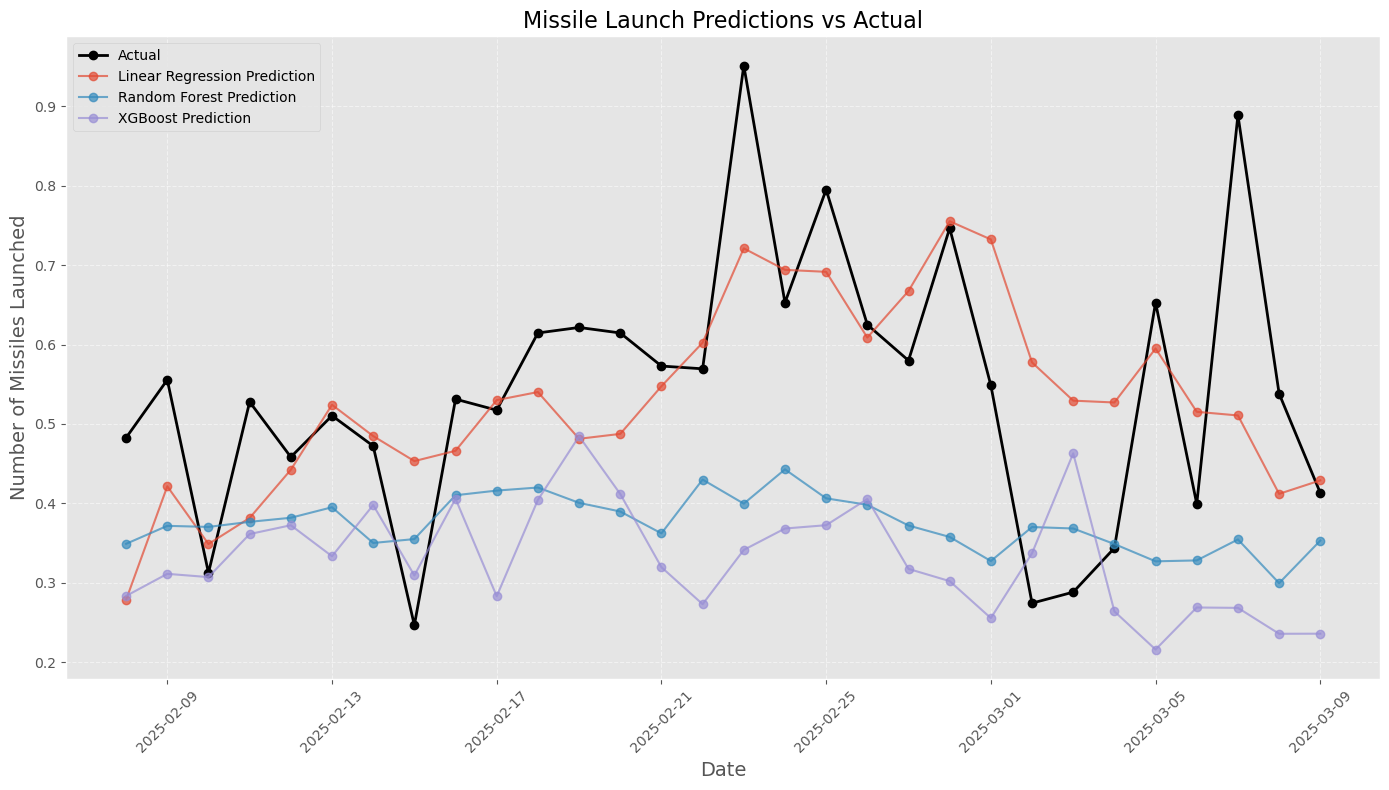


Best performing model: Linear Regression
MAE: 0.11
RMSE: 0.15
R2: 0.21


In [458]:
# Visualize predictions vs actual
plt.figure(figsize=(14, 8))
plt.plot(test['date'], y_test, 'o-', label='Actual', color='black', linewidth=2)

for name, result in results.items():
    plt.plot(test['date'], result['predictions'], 'o-', alpha=0.7, label=f'{name} Prediction')

plt.title('Missile Launch Predictions vs Actual', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Missiles Launched', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Identify the best performing model based on MAE
best_model_name = min(results, key=lambda x: results[x]['MAE'])
print(f"\nBest performing model: {best_model_name}")
print(f"MAE: {results[best_model_name]['MAE']:.2f}")
print(f"RMSE: {results[best_model_name]['RMSE']:.2f}")
print(f"R2: {results[best_model_name]['R2']:.2f}")

# If using tree-based model, show feature importance
if best_model_name in ['Random Forest', 'XGBoost']:
    best_model = models[best_model_name]
    
    # Get feature importance
    importance = best_model.feature_importances_
    
    # Create DataFrame for easier sorting and visualization
    feature_importance = pd.DataFrame({
        'Feature': features, 
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    # Plot top 15 features
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
    plt.title(f'Top 15 Most Important Features - {best_model_name}', fontsize=16)
    plt.xlabel('Importance', fontsize=14)
    plt.gca().invert_yaxis()  # To have the highest at the top
    plt.tight_layout()
    plt.show()

# Deeper Dive: Linear Regression

In [463]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define target variable
target = 'launched'

# Identify columns to exclude from features
exclude_cols = ['date', 'launched', 'destroyed', 'daily_personnel_losses']

# Create feature list
features = [col for col in df_model.columns if col not in exclude_cols]

# Create 90/10 split
test_fraction = 0.1
split_idx = int(len(df_model) * (1 - test_fraction))
train = df_model.iloc[:split_idx]
test = df_model.iloc[split_idx:]

# Prepare train and test sets
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Training on {len(train)} days, testing on {len(test)} days")
print(f"Train-test split: {len(train) / len(df_model):.1%} - {len(test) / len(df_model):.1%}")

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)
y_pred = np.maximum(y_pred, 0)  # Ensure non-negative predictions

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nLinear Regression Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Create coefficient DataFrame
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_
})

# Sort by absolute coefficient value
coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 Most Influential Features:")
pd.set_option('display.float_format', '{:.4f}'.format)
print(coefficients.head(10))

# Calculate intercept
print(f"\nIntercept: {lr_model.intercept_:.4f}")

Training on 777 days, testing on 87 days
Train-test split: 89.9% - 10.1%

Linear Regression Performance:
Mean Absolute Error (MAE): 0.13
Root Mean Squared Error (RMSE): 0.17
R² Score: 0.2678

Top 10 Most Influential Features:
             Feature  Coefficient  Abs_Coefficient
27    launched_roll7       1.4196           1.4196
12       day_of_year       1.3466           1.3466
8              month      -1.3065           1.3065
28   launched_roll30      -0.6395           0.6395
42  destroyed_roll30       0.4724           0.4724
7               year      -0.2829           0.2829
39   destroyed_lag14      -0.2633           0.2633
22     launched_lag1      -0.2524           0.2524
36    destroyed_lag1      -0.2350           0.2350
25    launched_lag14       0.2174           0.2174

Intercept: 0.0625


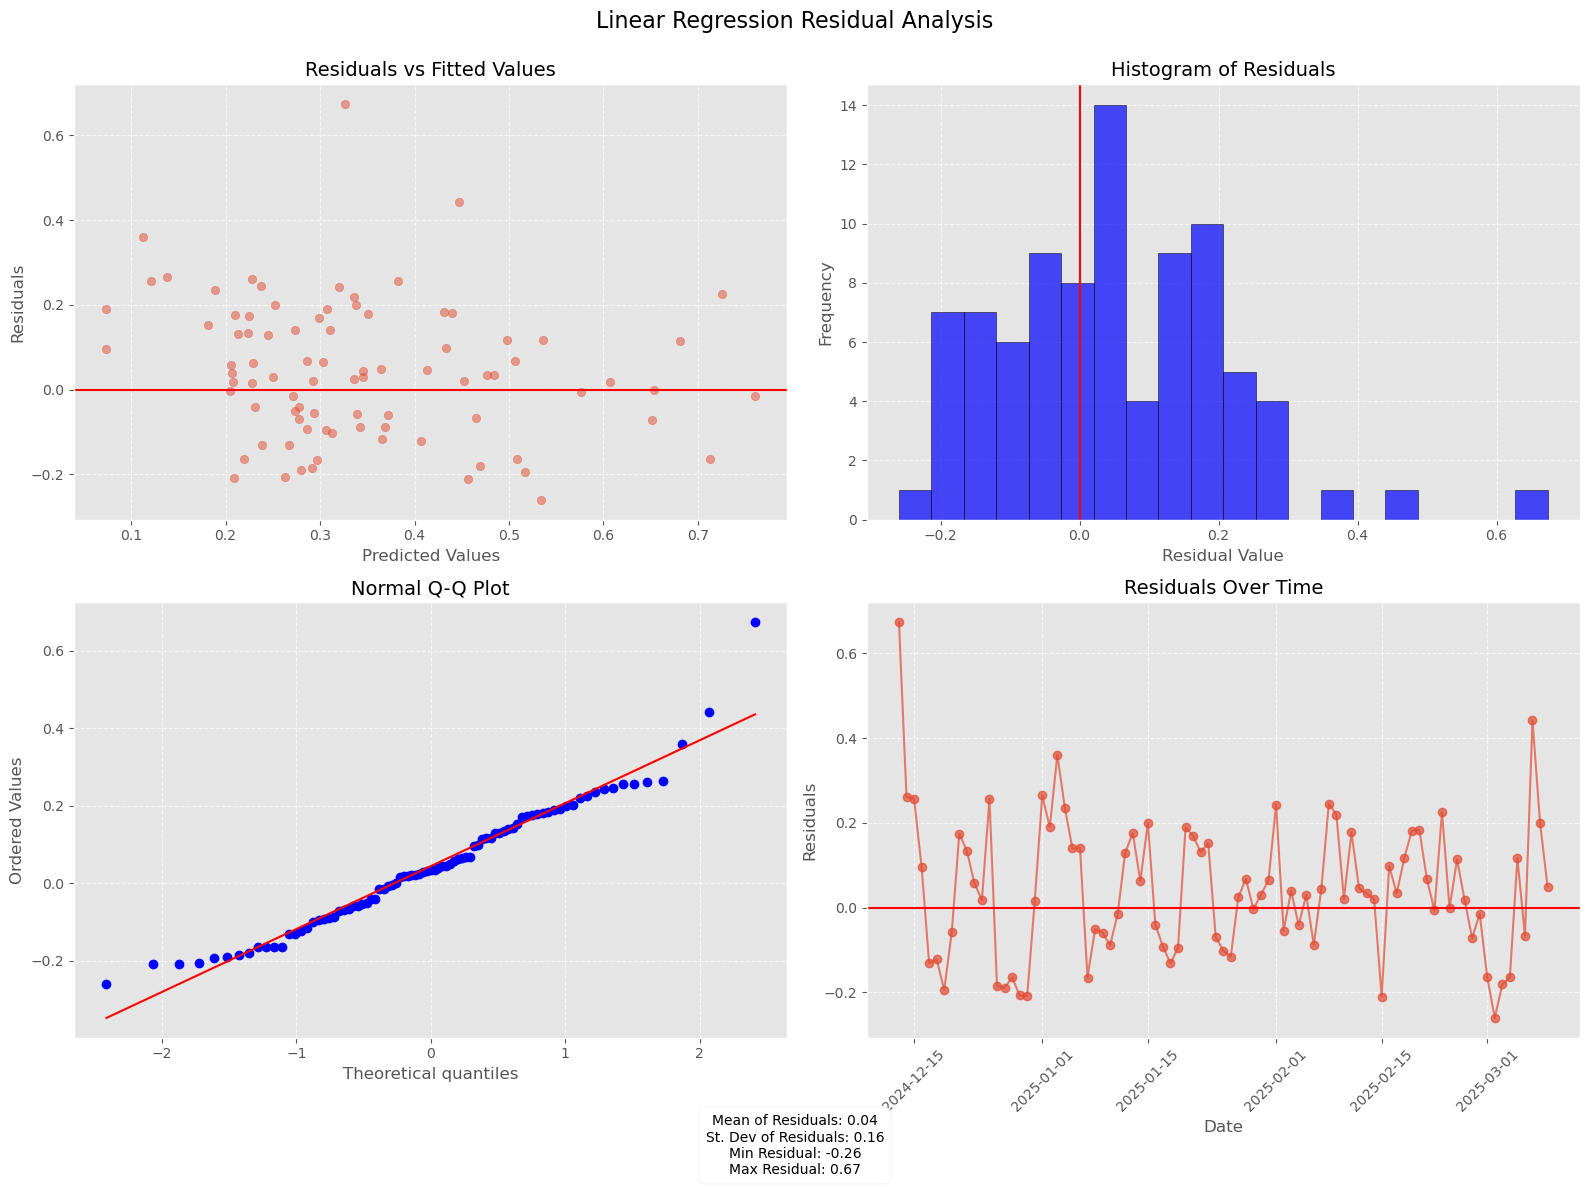

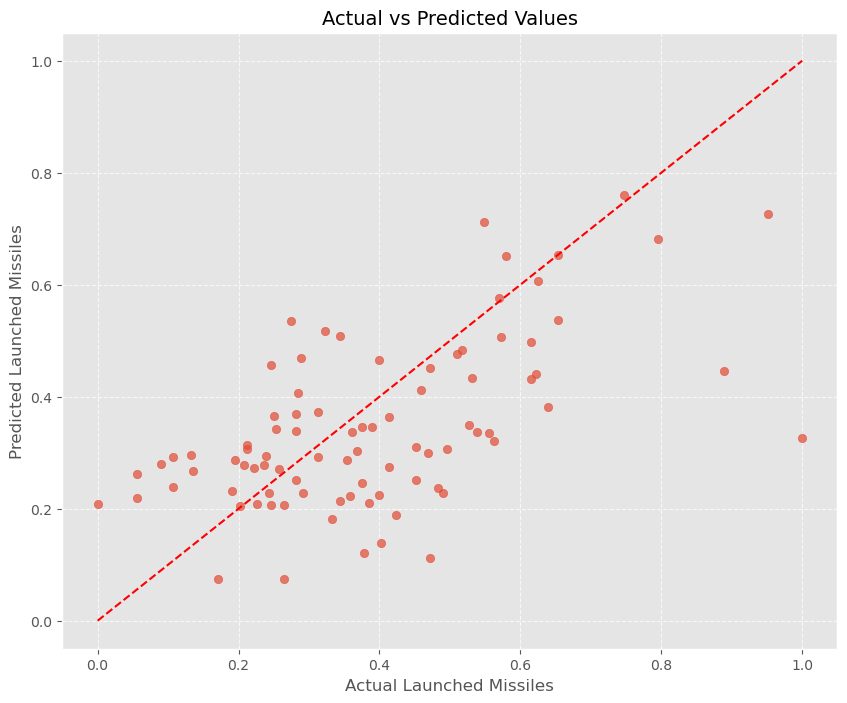

In [465]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred

# Create figure with multiple residual plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Residuals vs Fitted values
axes[0, 0].scatter(y_pred, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='-')
axes[0, 0].set_title('Residuals vs Fitted Values', fontsize=14)
axes[0, 0].set_xlabel('Predicted Values', fontsize=12)
axes[0, 0].set_ylabel('Residuals', fontsize=12)
axes[0, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Histogram of residuals
axes[0, 1].hist(residuals, bins=20, alpha=0.7, color='blue', edgecolor='black')
axes[0, 1].axvline(x=0, color='r', linestyle='-')
axes[0, 1].set_title('Histogram of Residuals', fontsize=14)
axes[0, 1].set_xlabel('Residual Value', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: QQ plot of residuals
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q Plot', fontsize=14)
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 4: Residuals over time
axes[1, 1].plot(test['date'], residuals, 'o-', alpha=0.7)
axes[1, 1].axhline(y=0, color='r', linestyle='-')
axes[1, 1].set_title('Residuals Over Time', fontsize=14)
axes[1, 1].set_xlabel('Date', fontsize=12)
axes[1, 1].set_ylabel('Residuals', fontsize=12)
axes[1, 1].grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Add summary statistics
stats_text = (f"Mean of Residuals: {np.mean(residuals):.2f}\n"
              f"St. Dev of Residuals: {np.std(residuals):.2f}\n"
              f"Min Residual: {min(residuals):.2f}\n"
              f"Max Residual: {max(residuals):.2f}")

fig.text(0.5, 0.01, stats_text, ha='center', 
         bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.5'))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Linear Regression Residual Analysis', fontsize=16, y=0.98)
plt.show()

# Additional analysis: Actual vs Predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title('Actual vs Predicted Values', fontsize=14)
plt.xlabel('Actual Launched Missiles', fontsize=12)
plt.ylabel('Predicted Launched Missiles', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

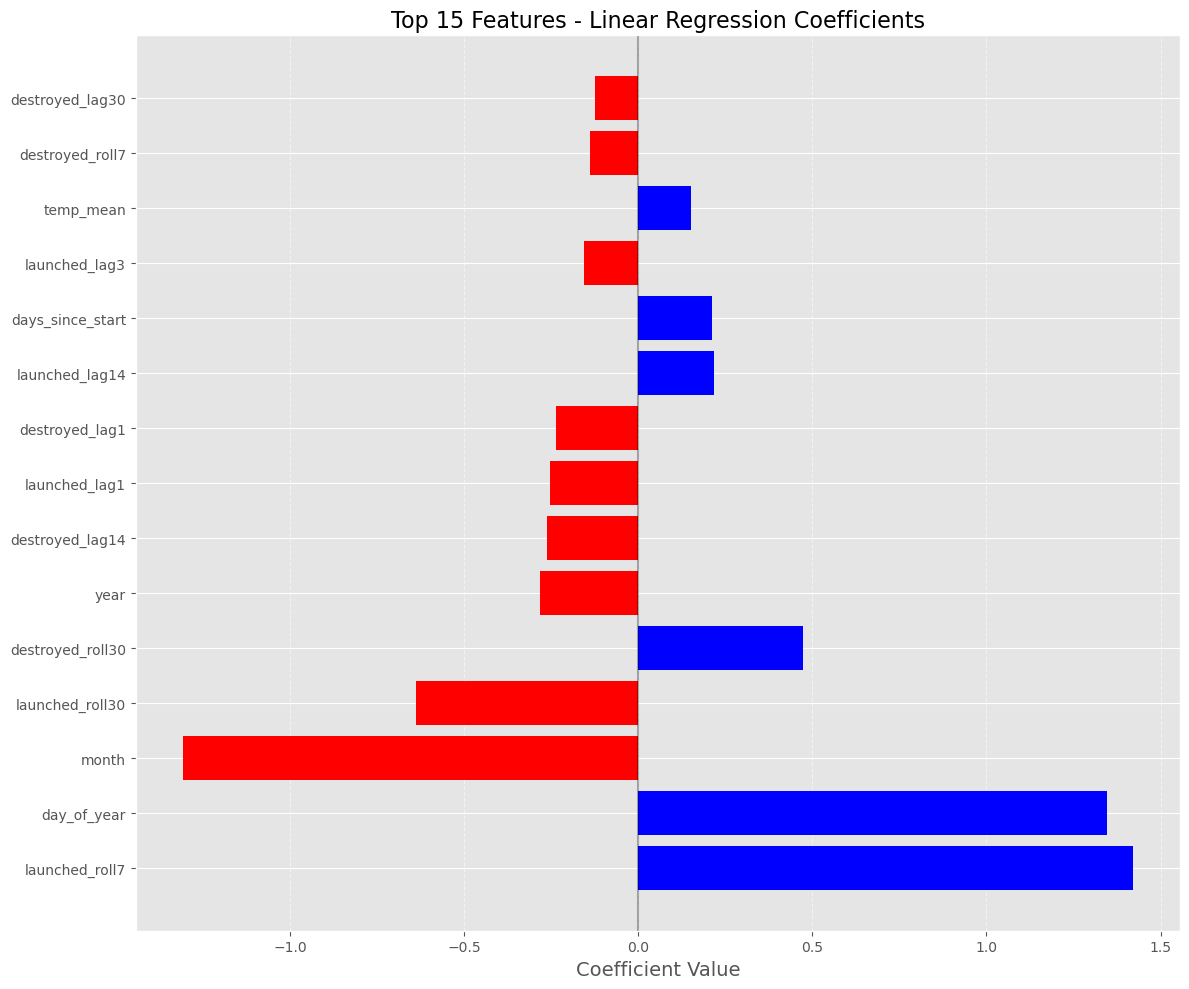

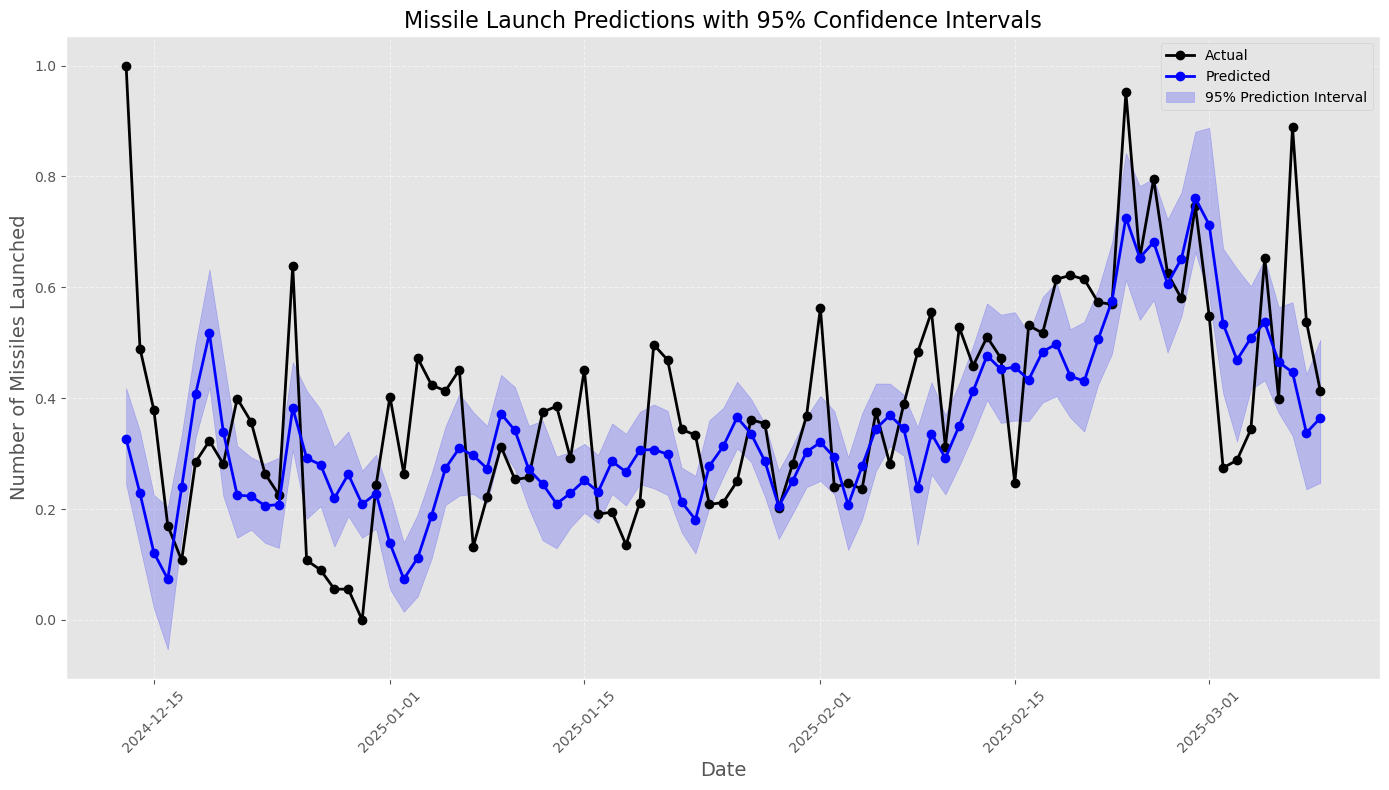

Percentage of actual values within 95% prediction interval: 37.9%

Forecast Error Metrics:
Mean Absolute Percentage Error (MAPE): 31.65%
Mean Forecast Error: 0.04
Standard Deviation of Forecast Errors: 0.16


In [467]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils import resample

# Create visualization of top features and their coefficients
fig, ax = plt.subplots(figsize=(12, 10))

# Get top 15 features by absolute coefficient value
top_features = coefficients.head(15)

# Create horizontal bar chart
colors = ['blue' if coef > 0 else 'red' for coef in top_features['Coefficient']]
ax.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax.set_title('Top 15 Features - Linear Regression Coefficients', fontsize=16)
ax.set_xlabel('Coefficient Value', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Bootstrap for prediction intervals
n_iterations = 1000
predictions = np.zeros((n_iterations, len(y_test)))

for i in range(n_iterations):
    # Create bootstrap sample
    indices = resample(range(len(X_train)), replace=True, n_samples=len(X_train))
    X_boot, y_boot = X_train.iloc[indices], y_train.iloc[indices]
    
    # Fit model on bootstrap sample
    boot_model = LinearRegression()
    boot_model.fit(X_boot, y_boot)
    
    # Generate predictions
    predictions[i] = boot_model.predict(X_test)

# Calculate prediction intervals
lower_bound = np.percentile(predictions, 2.5, axis=0)
upper_bound = np.percentile(predictions, 97.5, axis=0)

# Plot predictions with intervals
plt.figure(figsize=(14, 8))
plt.plot(test['date'], y_test, 'o-', label='Actual', color='black', linewidth=2)
plt.plot(test['date'], y_pred, 'o-', label='Predicted', color='blue', linewidth=2)
plt.fill_between(test['date'], lower_bound, upper_bound, color='blue', alpha=0.2, label='95% Prediction Interval')

plt.title('Missile Launch Predictions with 95% Confidence Intervals', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Missiles Launched', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate forecast accuracy metrics
within_interval = ((y_test >= lower_bound) & (y_test <= upper_bound)).mean()
print(f"Percentage of actual values within 95% prediction interval: {within_interval:.1%}")

# Calculate forecast error distribution
forecast_errors = y_test - y_pred
mape = np.mean(np.abs(forecast_errors / (y_test + 0.1))) * 100  # Adding 0.1 to avoid division by zero

print("\nForecast Error Metrics:")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Mean Forecast Error: {np.mean(forecast_errors):.2f}")
print(f"Standard Deviation of Forecast Errors: {np.std(forecast_errors):.2f}")

# Possion Regression 

In [472]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

# Set up Elastic Net with cross-validation to find optimal parameters
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_net = ElasticNet(random_state=42, max_iter=10000)
grid_search = GridSearchCV(
    estimator=elastic_net,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Fit on the training data
grid_search.fit(X_train, y_train)

# Best parameters and performance
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best MAE: {-grid_search.best_score_:.2f}")

# Evaluate on test set
best_elastic_net = grid_search.best_estimator_
y_pred_elastic = best_elastic_net.predict(X_test)
y_pred_elastic = np.maximum(y_pred_elastic, 0)  # Ensure non-negative predictions

mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
r2_elastic = r2_score(y_test, y_pred_elastic)

print("\nElastic Net Performance:")
print(f"MAE: {mae_elastic:.2f} (vs Linear Regression: {mae:.2f})")
print(f"RMSE: {rmse_elastic:.2f} (vs Linear Regression: {rmse:.2f})")
print(f"R²: {r2_elastic:.4f} (vs Linear Regression: {r2:.4f})")

Best parameters: {'alpha': 0.001, 'l1_ratio': 0.1}
Best MAE: 0.05

Elastic Net Performance:
MAE: 0.13 (vs Linear Regression: 0.13)
RMSE: 0.17 (vs Linear Regression: 0.17)
R²: 0.2843 (vs Linear Regression: 0.2678)


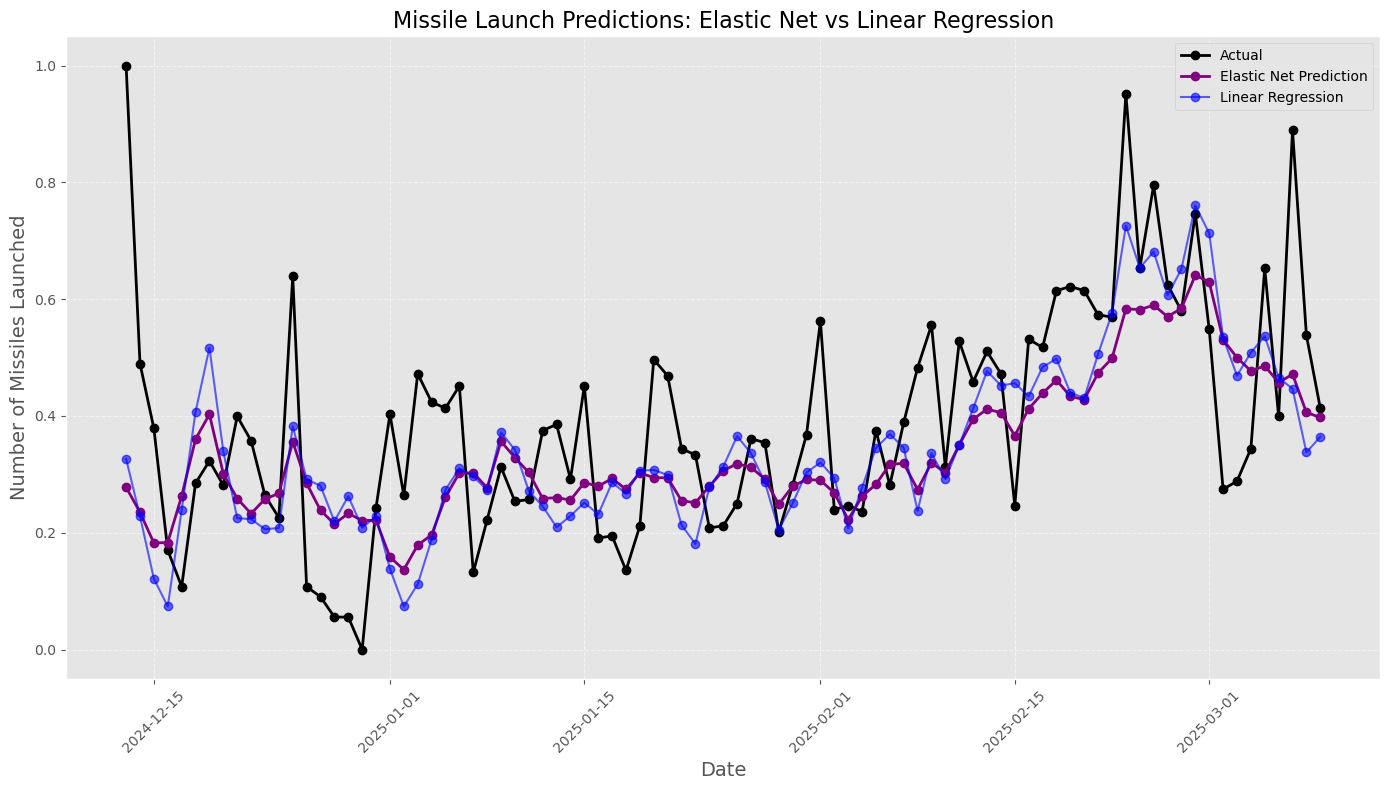

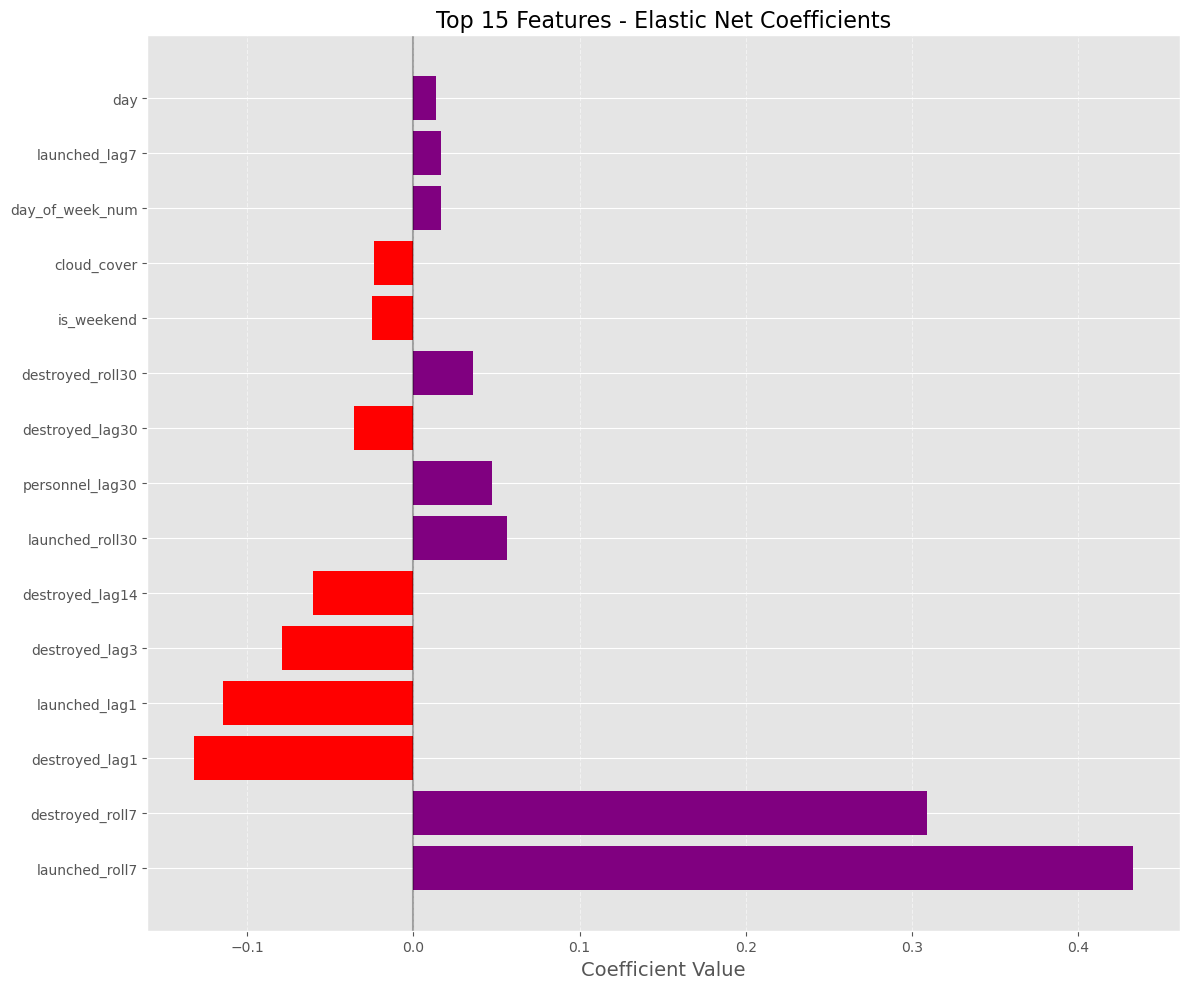

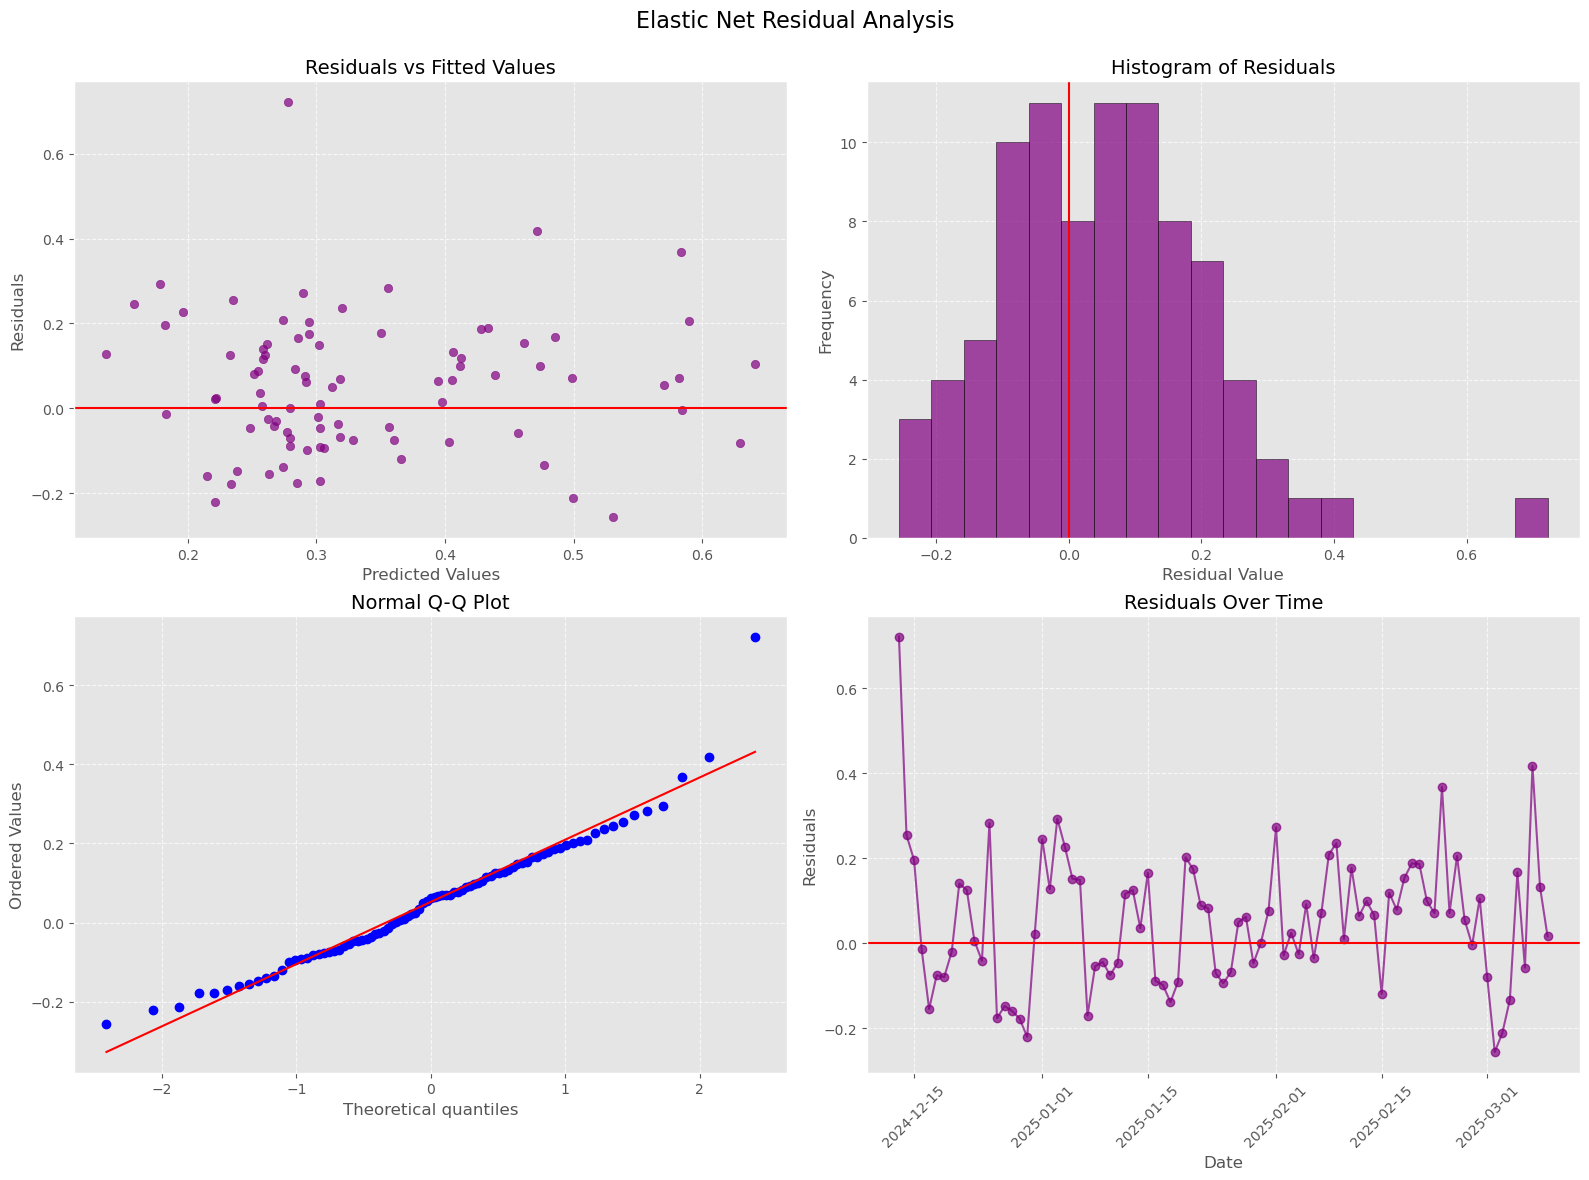

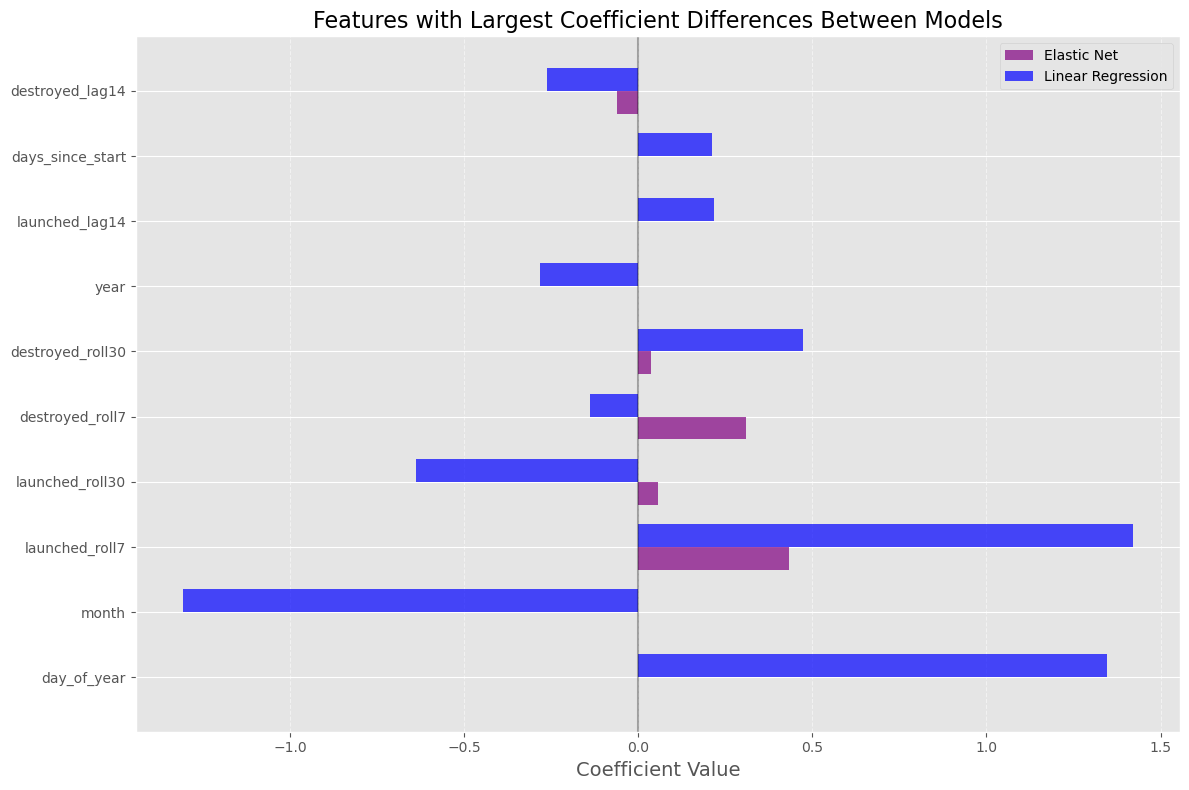

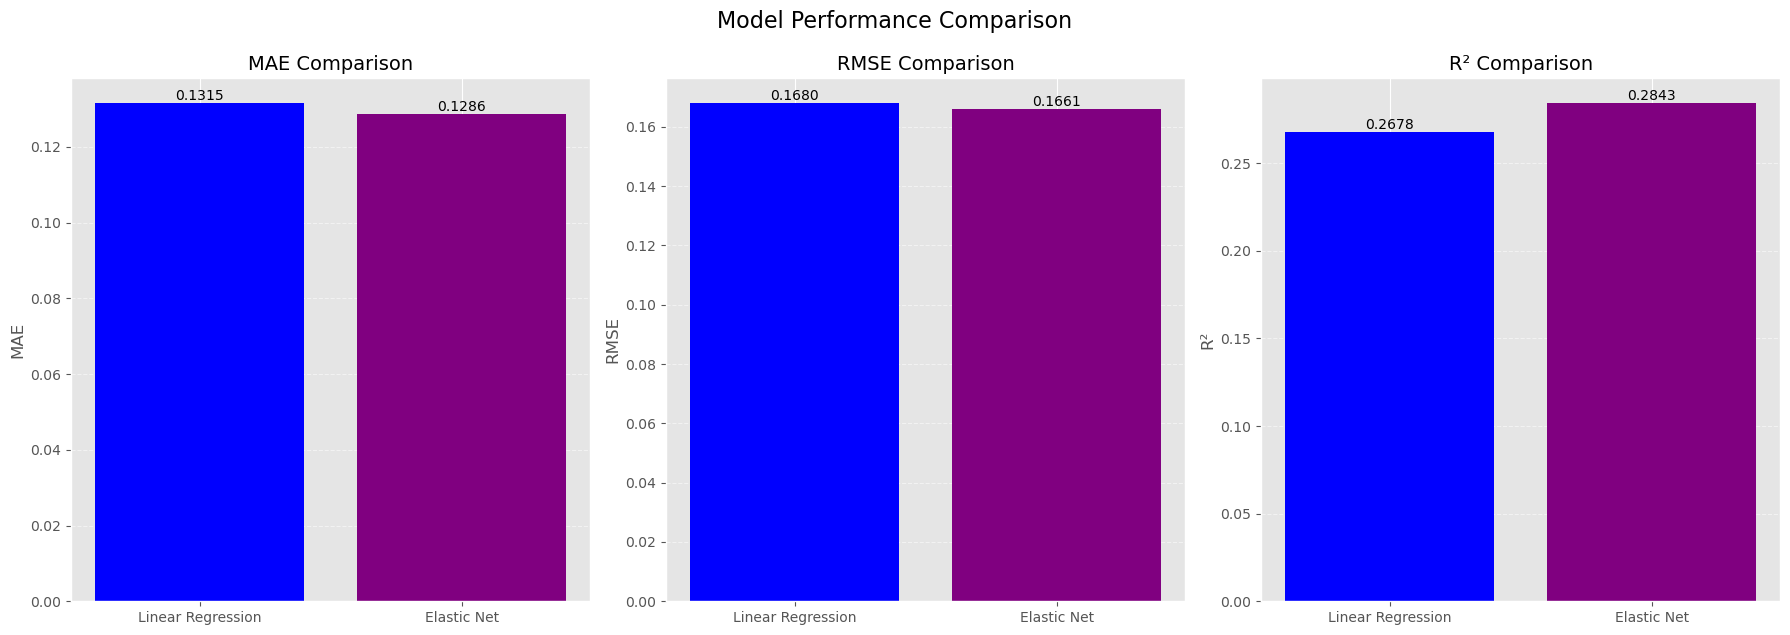

In [474]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Prediction vs. Actual Over Time
plt.figure(figsize=(14, 8))
plt.plot(test['date'], y_test, 'o-', label='Actual', color='black', linewidth=2)
plt.plot(test['date'], y_pred_elastic, 'o-', label='Elastic Net Prediction', color='purple', linewidth=2)
plt.plot(test['date'], y_pred, 'o-', label='Linear Regression', color='blue', alpha=0.6, linewidth=1.5)

plt.title('Missile Launch Predictions: Elastic Net vs Linear Regression', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Missiles Launched', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Feature Importance (Coefficients)
elastic_coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': best_elastic_net.coef_
})

# Sort by absolute coefficient value
elastic_coefficients['Abs_Coefficient'] = abs(elastic_coefficients['Coefficient'])
elastic_coefficients = elastic_coefficients.sort_values('Abs_Coefficient', ascending=False)

# Plot top 15 coefficients
plt.figure(figsize=(12, 10))
colors = ['purple' if coef > 0 else 'red' for coef in elastic_coefficients.head(15)['Coefficient']]
plt.barh(elastic_coefficients['Feature'][:15], elastic_coefficients['Coefficient'][:15], color=colors)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.title('Top 15 Features - Elastic Net Coefficients', fontsize=16)
plt.xlabel('Coefficient Value', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Residual Analysis
residuals_elastic = y_test - y_pred_elastic

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Residuals vs Fitted values
axes[0, 0].scatter(y_pred_elastic, residuals_elastic, alpha=0.7, color='purple')
axes[0, 0].axhline(y=0, color='r', linestyle='-')
axes[0, 0].set_title('Residuals vs Fitted Values', fontsize=14)
axes[0, 0].set_xlabel('Predicted Values', fontsize=12)
axes[0, 0].set_ylabel('Residuals', fontsize=12)
axes[0, 0].grid(True, linestyle='--', alpha=0.7)

# Histogram of residuals
axes[0, 1].hist(residuals_elastic, bins=20, alpha=0.7, color='purple', edgecolor='black')
axes[0, 1].axvline(x=0, color='r', linestyle='-')
axes[0, 1].set_title('Histogram of Residuals', fontsize=14)
axes[0, 1].set_xlabel('Residual Value', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].grid(True, linestyle='--', alpha=0.7)

# QQ plot
from scipy import stats
stats.probplot(residuals_elastic, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q Plot', fontsize=14)
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# Residuals over time
axes[1, 1].plot(test['date'], residuals_elastic, 'o-', alpha=0.7, color='purple')
axes[1, 1].axhline(y=0, color='r', linestyle='-')
axes[1, 1].set_title('Residuals Over Time', fontsize=14)
axes[1, 1].set_xlabel('Date', fontsize=12)
axes[1, 1].set_ylabel('Residuals', fontsize=12)
axes[1, 1].grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle('Elastic Net Residual Analysis', fontsize=16, y=0.98)
plt.subplots_adjust(top=0.92)
plt.show()

# 4. Coefficient Comparison: Elastic Net vs Linear Regression
# Merge coefficients from both models
comparison = pd.merge(
    elastic_coefficients[['Feature', 'Coefficient']].rename(columns={'Coefficient': 'Elastic_Net'}),
    coefficients[['Feature', 'Coefficient']].rename(columns={'Coefficient': 'Linear_Regression'}),
    on='Feature'
)

# Calculate absolute difference
comparison['Abs_Difference'] = abs(comparison['Elastic_Net'] - comparison['Linear_Regression'])
comparison = comparison.sort_values('Abs_Difference', ascending=False)

# Plot top features with biggest difference in coefficients
plt.figure(figsize=(12, 8))
top_diff = comparison.head(10)
ind = np.arange(len(top_diff))
width = 0.35

plt.barh(ind, top_diff['Elastic_Net'], width, label='Elastic Net', color='purple', alpha=0.7)
plt.barh(ind + width, top_diff['Linear_Regression'], width, label='Linear Regression', color='blue', alpha=0.7)

plt.yticks(ind + width/2, top_diff['Feature'])
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.title('Features with Largest Coefficient Differences Between Models', fontsize=16)
plt.xlabel('Coefficient Value', fontsize=14)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Model Performance Metrics Comparison
models = ['Linear Regression', 'Elastic Net']
metrics = {
    'MAE': [mae, mae_elastic],
    'RMSE': [rmse, rmse_elastic],
    'R²': [r2, r2_elastic]
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (metric_name, values) in enumerate(metrics.items()):
    axes[i].bar(models, values, color=['blue', 'purple'])
    axes[i].set_title(f'{metric_name} Comparison', fontsize=14)
    axes[i].set_ylabel(metric_name, fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    
    # Add value labels on top of bars
    for j, value in enumerate(values):
        axes[i].text(j, value, f'{value:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.suptitle('Model Performance Comparison', fontsize=16, y=1.05)
plt.show()

# Poisson Regression

In [477]:
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train Poisson Regression model
print("Training Poisson Regression model...")
poisson_model = PoissonRegressor(alpha=0.1, max_iter=1000)
poisson_model.fit(X_train, y_train)

# Make predictions
y_pred_poisson = poisson_model.predict(X_test)

# Calculate performance metrics
mae_poisson = mean_absolute_error(y_test, y_pred_poisson)
rmse_poisson = np.sqrt(mean_squared_error(y_test, y_pred_poisson))
r2_poisson = r2_score(y_test, y_pred_poisson)

print("\nPoisson Regression Performance:")
print(f"MAE: {mae_poisson:.2f}")
print(f"RMSE: {rmse_poisson:.2f}")
print(f"R²: {r2_poisson:.4f}")

# Compare with other models
print("\nModel Comparison:")
print(f"Linear Regression - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")
print(f"Elastic Net - MAE: {mae_elastic:.2f}, RMSE: {rmse_elastic:.2f}, R²: {r2_elastic:.4f}")
print(f"Poisson Regression - MAE: {mae_poisson:.2f}, RMSE: {rmse_poisson:.2f}, R²: {r2_poisson:.4f}")

# 2. Feature Coefficients
poisson_coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': poisson_model.coef_
})

# Sort by absolute coefficient value
poisson_coefficients['Abs_Coefficient'] = abs(poisson_coefficients['Coefficient'])
poisson_coefficients = poisson_coefficients.sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 Most Influential Features (Poisson):")
print(poisson_coefficients.head(10))

Training Poisson Regression model...

Poisson Regression Performance:
MAE: 0.29
RMSE: 0.34
R²: -2.0496

Model Comparison:
Linear Regression - MAE: 0.13, RMSE: 0.17, R²: 0.2678
Elastic Net - MAE: 0.13, RMSE: 0.17, R²: 0.2843
Poisson Regression - MAE: 0.29, RMSE: 0.34, R²: -2.0496

Top 10 Most Influential Features (Poisson):
             Feature  Coefficient  Abs_Coefficient
21  days_since_start       0.0976           0.0976
35  personnel_roll30       0.0895           0.0895
17       season_Fall       0.0877           0.0877
34   personnel_roll7       0.0782           0.0782
41   destroyed_roll7       0.0665           0.0665
42  destroyed_roll30       0.0655           0.0655
27    launched_roll7       0.0653           0.0653
28   launched_roll30       0.0624           0.0624
7               year       0.0612           0.0612
10           quarter       0.0585           0.0585


In [481]:
df_model.head()

,date,launched,destroyed,daily_personnel_losses,temp_max,temp_min,temp_mean,precip,wind_speed,cloud_cover,day_of_week_num,year,month,day,quarter,is_weekend,day_of_year,month_sin,month_cos,day_of_week_sin,day_of_week_cos,season_Fall,season_Spring,season_Summer,season_Winter,days_since_start,launched_lag1,launched_lag3,launched_lag7,launched_lag14,launched_lag30,launched_roll7,launched_roll30,personnel_lag1,personnel_lag3,personnel_lag7,personnel_lag14,personnel_lag30,personnel_roll7,personnel_roll30,destroyed_lag1,destroyed_lag3,destroyed_lag7,destroyed_lag14,destroyed_lag30,destroyed_roll7,destroyed_roll30
30,2022-10-28,0.0000,0.0000,0.0708,0.5407,0.5859,0.5611,0.0000,0.1366,0.8908,0.6667,0.0000,0.8182,0.9000,1.0000,0.0000,0.8219,0.0670,0.7500,0.2775,0.0000,True,False,False,False,0.0000,0.0729,0.0104,0.0000,0.0278,0.0278,0.0586,0.0867,0.0042,0.0708,0.0000,0.1905,0.1429,0.0339,0.0000,0.0000,0.0149,0.0000,0.0398,0.0348,0.0808,0.1171
31,2022-10-29,0.0000,0.0000,0.1000,0.5971,0.6167,0.6140,0.0026,0.4340,0.8513,0.8333,0.0000,0.8182,0.9333,1.0000,1.0000,0.8247,0.0670,0.7500,0.0000,0.3569,True,False,False,False,0.0012,0.0000,0.0729,0.1493,0.0208,0.0243,0.0282,0.0852,0.0708,0.0708,0.0843,0.1429,0.1571,0.0568,0.0032,0.0000,0.0995,0.1393,0.0299,0.0249,0.0470,0.1152
32,2022-10-30,0.0000,0.0000,0.2667,0.5324,0.6449,0.5785,0.0182,0.4138,0.9017,1.0000,0.0000,0.8182,0.9667,1.0000,1.0000,0.8274,0.0670,0.7500,0.0990,0.8019,True,False,False,False,0.0023,0.0000,0.0000,0.0556,0.0382,0.0104,0.0169,0.0845,0.1000,0.0042,0.1149,0.0952,0.1905,0.1117,0.0152,0.0000,0.0000,0.0796,0.0547,0.0149,0.0277,0.1140
33,2022-10-31,0.1736,0.2189,0.1292,0.4520,0.4692,0.4729,0.0000,0.4846,0.1679,0.0000,0.0000,0.8182,1.0000,1.0000,0.0000,0.8301,0.0670,0.7500,0.5000,1.0000,True,False,False,False,0.0035,0.0000,0.0000,0.0000,0.1354,0.0035,0.0522,0.0951,0.2667,0.0708,0.1418,0.1048,0.2048,0.1266,0.0175,0.0000,0.0000,0.0000,0.1940,0.0050,0.0808,0.1303
34,2022-11-01,0.0243,0.0348,0.1417,0.4415,0.4308,0.4307,0.0000,0.1409,0.3987,0.1667,0.0000,0.9091,0.0000,1.0000,0.0000,0.8329,0.2500,0.9330,0.9010,0.8019,True,False,False,False,0.0046,0.0000,0.0000,0.0104,0.0382,0.0243,0.0550,0.0951,0.1292,0.1000,0.1456,0.2048,0.1905,0.1436,0.0215,0.2189,0.0000,0.0149,0.0547,0.0249,0.0856,0.1310


Using 39 features for LSTM
Training sequences shape: (771, 7, 39)
Testing sequences shape: (86, 7, 39)
LSTMModel(
  (lstm): LSTM(39, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Training LSTM model...
Epoch [10/100], Loss: 0.0099
Epoch [20/100], Loss: 0.0083
Epoch [30/100], Loss: 0.0087
Epoch [40/100], Loss: 0.0074
Epoch [50/100], Loss: 0.0071
Epoch [60/100], Loss: 0.0067
Epoch [70/100], Loss: 0.0065
Epoch [80/100], Loss: 0.0057
Epoch [90/100], Loss: 0.0050
Epoch [100/100], Loss: 0.0045

LSTM Model Performance:
MAE: 0.2531
RMSE: 0.3064
R²: -1.7146

Model Comparison:
Linear Regression - MAE: 0.1315, RMSE: 0.1680, R²: 0.2678
Elastic Net - MAE: 0.1286, RMSE: 0.1661, R²: 0.2843
LSTM - MAE: 0.2531, RMSE: 0.3064, R²: -1.7146


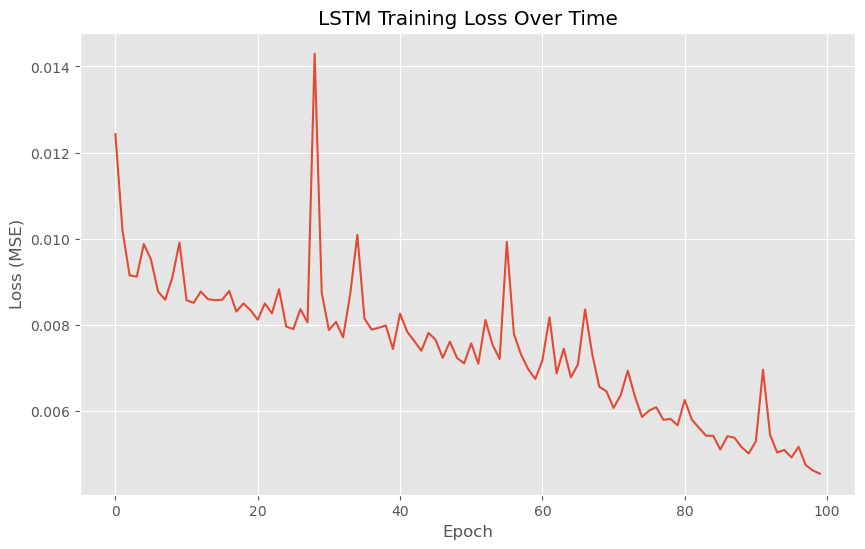

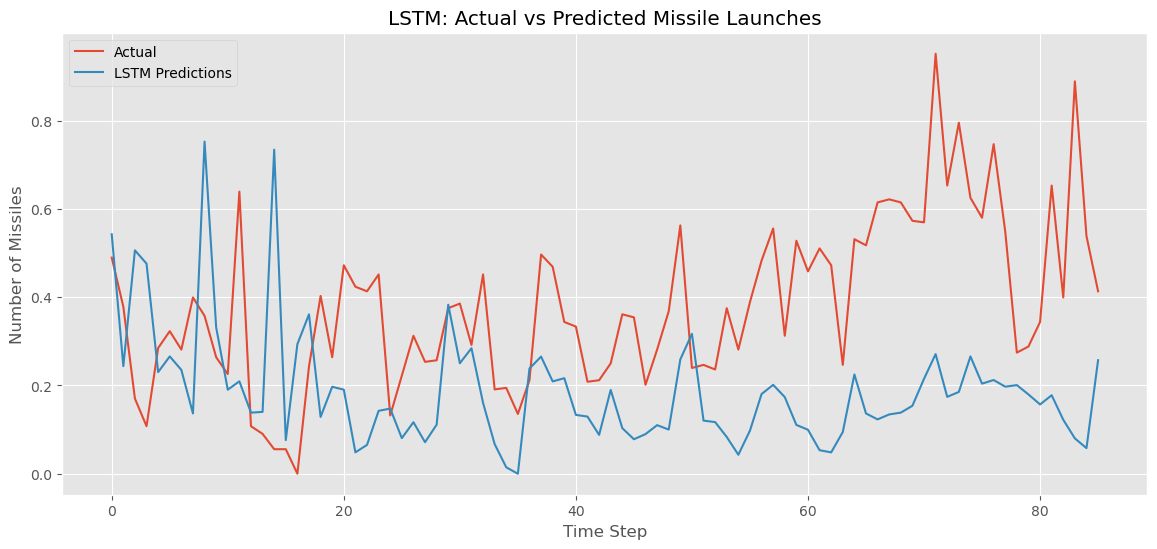

In [483]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define target and features
target = 'launched'
exclude_cols = ['date', 'launched', 'destroyed', 'daily_personnel_losses']

# Create sequence data for LSTM
def create_sequences(data, features, target_col, seq_length=7):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[features].iloc[i:i+seq_length].values)
        y.append(data[target_col].iloc[i+seq_length])
    return np.array(X), np.array(y)

# Select only numeric columns
numeric_cols = df_model.select_dtypes(include=['int', 'float']).columns.tolist()
features = [col for col in numeric_cols if col not in exclude_cols]

print(f"Using {len(features)} features for LSTM")

# Create sequences with 7-day lookback
seq_length = 7
X_sequences, y_sequences = create_sequences(df_model, features, target, seq_length)

# Split data (90/10)
split_idx = int(len(X_sequences) * 0.9)
X_train_seq = X_sequences[:split_idx]
y_train_seq = y_sequences[:split_idx]
X_test_seq = X_sequences[split_idx:]
y_test_seq = y_sequences[split_idx:]

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Testing sequences shape: {X_test_seq.shape}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_seq)
y_train_tensor = torch.FloatTensor(y_train_seq).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_seq)
y_test_tensor = torch.FloatTensor(y_test_seq).view(-1, 1)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))  # out: batch_size, seq_length, hidden_dim
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Initialize model
input_dim = X_train_seq.shape[2]  # Number of features
model = LSTMModel(input_dim=input_dim)
print(model)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 100
losses = []

print("Training LSTM model...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')

# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred_lstm = y_pred_tensor.numpy().flatten()
    
# Ensure non-negative predictions
y_pred_lstm = np.maximum(y_pred_lstm, 0)

# Calculate metrics
mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
r2_lstm = r2_score(y_test_seq, y_pred_lstm)

print("\nLSTM Model Performance:")
print(f"MAE: {mae_lstm:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")
print(f"R²: {r2_lstm:.4f}")

print("\nModel Comparison:")
print(f"Linear Regression - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")
print(f"Elastic Net - MAE: {mae_elastic:.4f}, RMSE: {rmse_elastic:.4f}, R²: {r2_elastic:.4f}")
print(f"LSTM - MAE: {mae_lstm:.4f}, RMSE: {rmse_lstm:.4f}, R²: {r2_lstm:.4f}")

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('LSTM Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

# Plot predictions vs actual
plt.figure(figsize=(14, 6))
plt.plot(y_test_seq, label='Actual')
plt.plot(y_pred_lstm, label='LSTM Predictions')
plt.title('LSTM: Actual vs Predicted Missile Launches')
plt.xlabel('Time Step')
plt.ylabel('Number of Missiles')
plt.legend()
plt.grid(True)
plt.show()

### Why LSTM Underperformed:

1. **Linear relationships dominate**: This reinforces what we discovered earlier - the relationship between your features and missile launches appears to be predominantly linear

2. **Not enough data for sequence learning**: LSTMs need substantial data to learn complex temporal patterns. With only 771 training sequences, it's difficult for the model to generalize properly

3. **Feature engineering already captured temporal patterns**: Your extensive feature engineering (lag features, rolling averages, cyclical encodings) already encoded much of the temporal information in a format that linear models can easily use

4. **Possible overfitting**: The LSTM might be overfitting to noise in the training data rather than learning true patterns

### What We've Learned:

This exploration across multiple model types has actually been very valuable. It's confirmed that:

1. **Elastic Net is your best model** with an R² of 0.2843, slightly outperforming Linear Regression

2. **Feature engineering matters more than model complexity** in this case - your carefully engineered features enabled simple models to perform well

3. **The missile launch data has predominantly linear relationships** with the predictors

### Recommendations:

1. **Use the Elastic Net model** for your final predictions

2. **Extract feature importance** from the Elastic Net model to understand key drivers of missile launches

3. **Focus on interpretability**: Create clear visualizations showing how the top predictive features relate to launches

4. **Consider creating an ensemble**: If you want to squeeze out a bit more performance, you could create a weighted average of predictions from your top models

This is actually a great example of the principle that simpler models often perform better on real-world data, especially when combined with thoughtful feature engineering!

# What if we take elastic net and do this without outliers in our data? 

Identified 72 outliers out of 864 records (8.3%)
Outlier threshold: > 0.4
Max value: 1.0

Elastic Net Performance (without outliers):
MAE: 0.0749
RMSE: 0.0907
R²: 0.1214

Comparison with original Elastic Net:
Original - MAE: 0.1286, RMSE: 0.1661, R²: 0.2843
Without Outliers - MAE: 0.0749, RMSE: 0.0907, R²: 0.1214


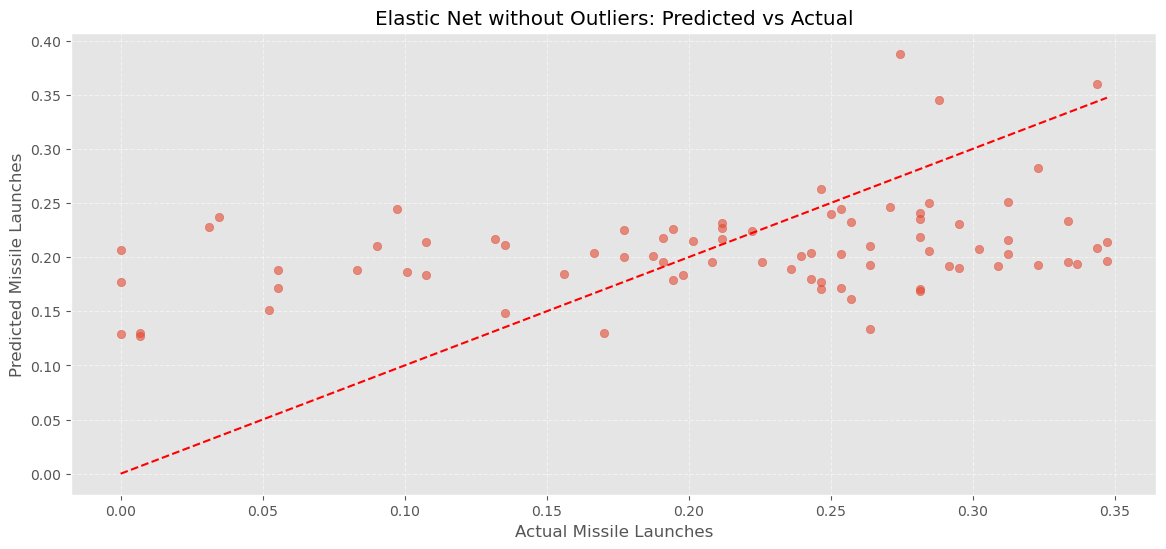

In [488]:
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Identify outliers using IQR method
Q1 = df_model['launched'].quantile(0.25)
Q3 = df_model['launched'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = (df_model['launched'] > upper_bound) | (df_model['launched'] < lower_bound)
outlier_indices = df_model[outliers].index

# Print outlier statistics
print(f"Identified {outliers.sum()} outliers out of {len(df_model)} records ({outliers.sum()/len(df_model):.1%})")
print(f"Outlier threshold: > {upper_bound:.1f}")
print(f"Max value: {df_model['launched'].max():.1f}")

# Create dataset without outliers
df_no_outliers = df_model[~outliers].copy()

# Define features and target
target = 'launched'
exclude_cols = ['date', 'launched', 'destroyed', 'daily_personnel_losses']
features = [col for col in df_no_outliers.columns if col not in exclude_cols]

# Split into train and test (90/10 split)
split_idx = int(len(df_no_outliers) * 0.9)
train_no_out = df_no_outliers.iloc[:split_idx]
test_no_out = df_no_outliers.iloc[split_idx:]

X_train_no_out = train_no_out[features]
y_train_no_out = train_no_out[target]
X_test_no_out = test_no_out[features]
y_test_no_out = test_no_out[target]

# Train Elastic Net on data without outliers
elastic_net_no_out = ElasticNet(alpha=0.001, l1_ratio=0.1, max_iter=10000, random_state=42)
elastic_net_no_out.fit(X_train_no_out, y_train_no_out)

# Predict on test set
y_pred_no_out = elastic_net_no_out.predict(X_test_no_out)

# Calculate metrics
mae_no_out = mean_absolute_error(y_test_no_out, y_pred_no_out)
rmse_no_out = np.sqrt(mean_squared_error(y_test_no_out, y_pred_no_out))
r2_no_out = r2_score(y_test_no_out, y_pred_no_out)

print("\nElastic Net Performance (without outliers):")
print(f"MAE: {mae_no_out:.4f}")
print(f"RMSE: {rmse_no_out:.4f}")
print(f"R²: {r2_no_out:.4f}")

print("\nComparison with original Elastic Net:")
print(f"Original - MAE: {mae_elastic:.4f}, RMSE: {rmse_elastic:.4f}, R²: {r2_elastic:.4f}")
print(f"Without Outliers - MAE: {mae_no_out:.4f}, RMSE: {rmse_no_out:.4f}, R²: {r2_no_out:.4f}")

# Visualize predictions vs. actual
plt.figure(figsize=(14, 6))
plt.scatter(y_test_no_out, y_pred_no_out, alpha=0.6)
plt.plot([0, max(y_test_no_out)], [0, max(y_test_no_out)], 'r--')
plt.xlabel('Actual Missile Launches')
plt.ylabel('Predicted Missile Launches')
plt.title('Elastic Net without Outliers: Predicted vs Actual')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Weekly data shape: (120, 18)
Training on 96 weeks, testing on 24 weeks

Weekly Elastic Net Performance:
MAE: 0.8103
RMSE: 1.0132
R²: -0.4378


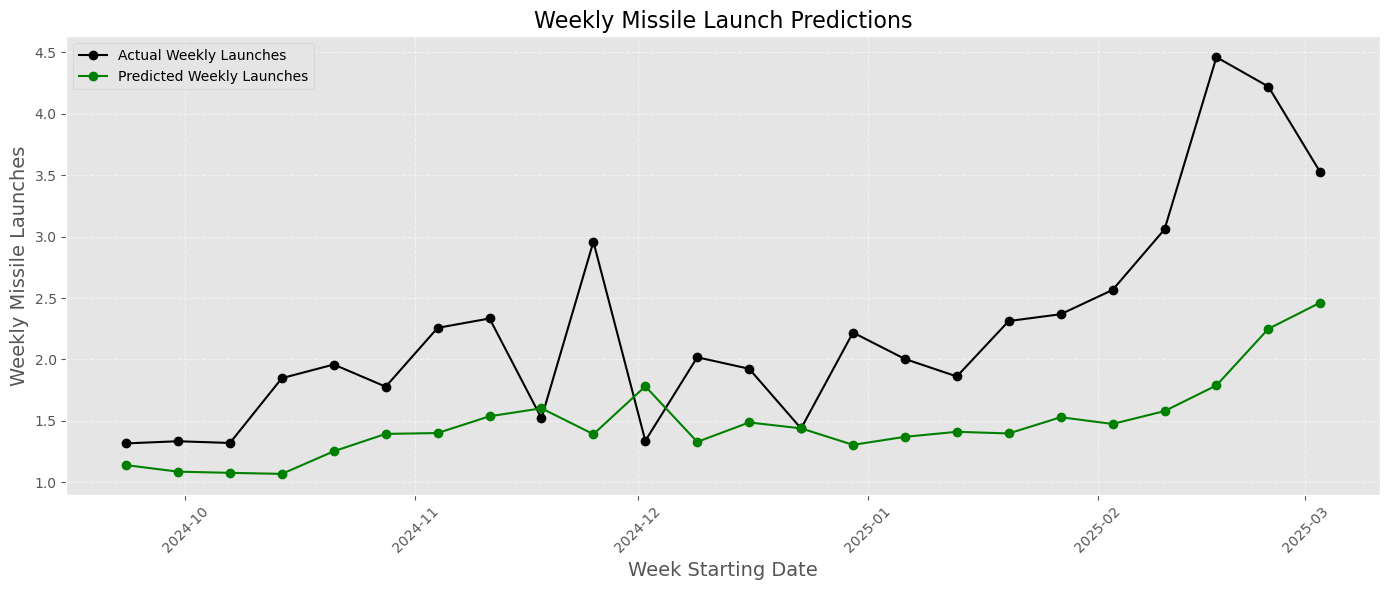

In [490]:
# Aggregate data to weekly level
df_weekly = df_model.copy()
df_weekly['week_start'] = df_weekly['date'] - pd.to_timedelta(df_weekly['date'].dt.dayofweek, unit='d')

# Group by week and aggregate
weekly_agg = df_weekly.groupby('week_start').agg({
    'launched': 'sum',
    'destroyed': 'sum',
    'daily_personnel_losses': 'sum',
    'temp_mean': 'mean',
    'precip': 'sum',
    'wind_speed': 'mean',
    'cloud_cover': 'mean',
    'is_weekend': 'mean',  # Proportion of weekend days
    'year': 'first',
    'month': 'mean',
    'day_of_year': 'mean'
    # Add other relevant columns as needed
}).reset_index()

# Create lag features at weekly level
weekly_agg['launched_lag1'] = weekly_agg['launched'].shift(1)
weekly_agg['launched_lag2'] = weekly_agg['launched'].shift(2)
weekly_agg['launched_lag3'] = weekly_agg['launched'].shift(3)
weekly_agg['launched_lag4'] = weekly_agg['launched'].shift(4)
weekly_agg['destroyed_lag1'] = weekly_agg['destroyed'].shift(1)
weekly_agg['losses_lag1'] = weekly_agg['daily_personnel_losses'].shift(1)

# Drop NaNs from lags
weekly_agg = weekly_agg.dropna()

# Define features and target for weekly model
target_weekly = 'launched'
exclude_cols_weekly = ['week_start', 'launched', 'destroyed', 'daily_personnel_losses']
features_weekly = [col for col in weekly_agg.columns if col not in exclude_cols_weekly]

# Split weekly data (80/20 due to fewer rows)
split_idx_weekly = int(len(weekly_agg) * 0.8)
train_weekly = weekly_agg.iloc[:split_idx_weekly]
test_weekly = weekly_agg.iloc[split_idx_weekly:]

X_train_weekly = train_weekly[features_weekly]
y_train_weekly = train_weekly[target_weekly]
X_test_weekly = test_weekly[features_weekly]
y_test_weekly = test_weekly[target_weekly]

print(f"Weekly data shape: {weekly_agg.shape}")
print(f"Training on {len(train_weekly)} weeks, testing on {len(test_weekly)} weeks")

# Train Elastic Net on weekly data
elastic_net_weekly = ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=10000, random_state=42)
elastic_net_weekly.fit(X_train_weekly, y_train_weekly)

# Predict on test set
y_pred_weekly = elastic_net_weekly.predict(X_test_weekly)

# Calculate metrics
mae_weekly = mean_absolute_error(y_test_weekly, y_pred_weekly)
rmse_weekly = np.sqrt(mean_squared_error(y_test_weekly, y_pred_weekly))
r2_weekly = r2_score(y_test_weekly, y_pred_weekly)

print("\nWeekly Elastic Net Performance:")
print(f"MAE: {mae_weekly:.4f}")
print(f"RMSE: {rmse_weekly:.4f}")
print(f"R²: {r2_weekly:.4f}")

# Visualize weekly predictions
plt.figure(figsize=(14, 6))
plt.plot(test_weekly['week_start'], y_test_weekly, 'o-', label='Actual Weekly Launches', color='black')
plt.plot(test_weekly['week_start'], y_pred_weekly, 'o-', label='Predicted Weekly Launches', color='green')
plt.title('Weekly Missile Launch Predictions', fontsize=16)
plt.xlabel('Week Starting Date', fontsize=14)
plt.ylabel('Weekly Missile Launches', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()